# Chapter 7 Determinants: Exercises

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/asj252/linear-algebra-with-python/blob/main/en/EN_Chap7_Determinant_Exercises.ipynb) [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/asj252/linear-algebra-with-python/HEAD?labpath=en%2FEN_Chap7_Determinant_Exercises.ipynb)

Compiled from the original manuscript of Chapter 7 exercises provided by Professor Ping-Zen Ong: 36 top-level exercises in all, in the same order as in the manuscript. Every exercise comes with a hint and a complete solution that can be expanded; computational exercises are followed by a NumPy verification, while pure proof exercises have no accompanying program.

This part uses 0-based indexing, and permutations are written as lists of images. Inconsistent notation and ambiguities in the statements of the original manuscript are noted in the corresponding exercises.

In [1]:
import numpy as np
np.set_printoptions(precision=4, suppress=True, linewidth=100)

def print_header(title):
    print("=" * 60)
    print(f"  {title}")
    print("=" * 60)

def print_step(step, desc):
    print(f"\n▶ Step {step}: {desc}")
    print("-" * 40)

def compare_print(label, actual, expected_desc):
    print(f"\n[{label}]")
    print(f"  Computed value: {actual}")
    print(f"  Expected value: {expected_desc}")

def check(label, actual, expected):
    compare_print(label, actual, expected)
    assert np.allclose(actual, expected), label
    print("  check passed")

def rref(A, tol=1e-10):
    """Gauss–Jordan elimination with partial pivoting; only for the small numerical examples of this chapter."""
    R = np.array(A, dtype=float, copy=True)
    row = 0
    for col in range(R.shape[1]):
        if row == R.shape[0]:
            break
        pivot = row + np.argmax(np.abs(R[row:, col]))
        if abs(R[pivot, col]) <= tol:
            continue
        R[[row, pivot]] = R[[pivot, row]]
        R[row] /= R[row, col]
        for i in range(R.shape[0]):
            if i != row:
                R[i] -= R[i, col] * R[row]
        row += 1
    R[np.abs(R) < tol] = 0
    return R

def lu_no_pivot(A):
    """Only for the square matrices in this book whose first n-1 pivots are nonzero."""
    U = np.array(A, dtype=float, copy=True)
    n = len(U)
    L = np.eye(n)
    for j in range(n - 1):
        assert abs(U[j, j]) > 1e-10, "zero pivot: this function does not exchange rows"
        for i in range(j + 1, n):
            L[i, j] = U[i, j] / U[j, j]
            U[i] -= L[i, j] * U[j]
    return L, U

from itertools import permutations
import matplotlib.pyplot as plt

# --- Color palette (Accent Mix) ---
C_BG = "#F8F8F8"
C_GRID = "#D6D6D6"
C_AXIS = "#000000"
C_V1 = "#57068C"
C_V2 = "#006385"
C_T1 = "#2AD2C9"
C_T2 = "#8900E1"
C_WARN = "#FF5D47"
C_AUX = "#AB82C5"
C_AREA = "rgba(87, 6, 140, 0.25)"  # for Plotly only.
# Fonts: the English edition needs no CJK font, so nothing is downloaded when _lang == 'en';
# the Chinese editions use this same block to fetch Noto Sans TC/SC where no CJK font is installed
import os, urllib.request
import matplotlib.font_manager as fm
_lang = 'en'
_cjk = ['Microsoft JhengHei', 'PingFang TC', 'Noto Sans CJK TC', 'Noto Sans TC']
_have = {f.name for f in fm.fontManager.ttflist}
if _lang != 'en' and not _have & set(_cjk):
    _font = os.path.join(os.path.expanduser('~'), '.cache', 'fonts', 'NotoSansTC.ttf')
    try:
        if not os.path.exists(_font):
            os.makedirs(os.path.dirname(_font), exist_ok=True)
            urllib.request.urlretrieve('https://github.com/google/fonts/raw/main/ofl/notosanstc/NotoSansTC%5Bwght%5D.ttf', _font + '.part')
            os.replace(_font + '.part', _font)
        fm.fontManager.addfont(_font)
        _have.add('Noto Sans TC')
    except OSError as err:
        print('Could not download the CJK font; Chinese text in figures may not display:', err)
plt.rcParams['font.family'] = [f for f in _cjk if f in _have] + ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def inversion_count(sigma):
    return sum(sigma[i] > sigma[j] for i in range(len(sigma)) for j in range(i+1,len(sigma)))

def permutation_sign(sigma):
    return (-1)**int(inversion_count(sigma))

def cofactor(A, i, j):
    minor = np.delete(np.delete(A, i, axis=0), j, axis=1)
    return (-1)**(i+j) * np.linalg.det(minor)


### Permutations, Inversions, and the Classical Definition

::::{exercise} Inversions and Crossings
:label: exer-ch7-inversions-crossings

On $\{0,1,2,3,4\}$, let the permutation have the list of images $\sigma=[3,0,4,1,2]$, that is, $\sigma(0)=3,\sigma(1)=0,\sigma(2)=4,\sigma(3)=1,\sigma(4)=2$.
1. Compute the number of inversions and its parity.
2. Compute $\operatorname{sgn}(\sigma)$.
3. Write $0,1,2,3,4$ in the top row and $3,0,4,1,2$ in the bottom row, and connect equal numbers in the two rows; count the pairs of crossing segments and compare with the number of inversions (the figure is in the output of the program for this exercise).
4. Associating $1$ with even and $-1$ with odd, compare the three parities above.

**Notation.** Throughout this part, square brackets always denote a list of images, not cycle notation; the $1$–$5$ of the original manuscript have been changed to $0$–$4$ accordingly.

**Hint.** List all pairs with $i<j$ and $\sigma(i)>\sigma(j)$.

:::{solution} exer-ch7-inversions-crossings
:class: dropdown

**Step 1.** The inverted index pairs are $(0,1),(0,3),(0,4),(2,3),(2,4)$, $\underline{5}$ in all, which is odd, so $\underline{\operatorname{sgn}(\sigma)=(-1)^5=-1}$.

**Step 2.** The line from the number $j$ on top goes to position $\sigma^{-1}(j)$ in the bottom row, and $\sigma^{-1}=[1,3,4,0,2]$. The pairs of numbers whose lines cross are $(0,3),(1,3),(1,4),(2,3),(2,4)$, $5$ pairs in all; in this figure the five crossing points are also distinct.

**Step 3.** An inversion $(i,j)$ corresponds to the inversion $(\sigma(j),\sigma(i))$ of the inverse permutation, so the two counts are equal. All three tests give $\underline{-1}$. In a general diagram one should count "pairs of crossing segments"; if several lines pass through a common point, it is not enough to count the distinct geometric positions.
:::
::::

  Exercise 7-1 | Inversions and Crossings

▶ Step 1: Compute the number of inversions and the inverse permutation
----------------------------------------

[number of inversions]
  Computed value: 5
  Expected value: 5
  check passed

[sgn(σ)]
  Computed value: -1
  Expected value: -1
  check passed

[pairs of crossing segments]
  Computed value: 5
  Expected value: 5
  check passed

▶ Step 2: Draw the permutation diagram joining equal values in the two rows
----------------------------------------


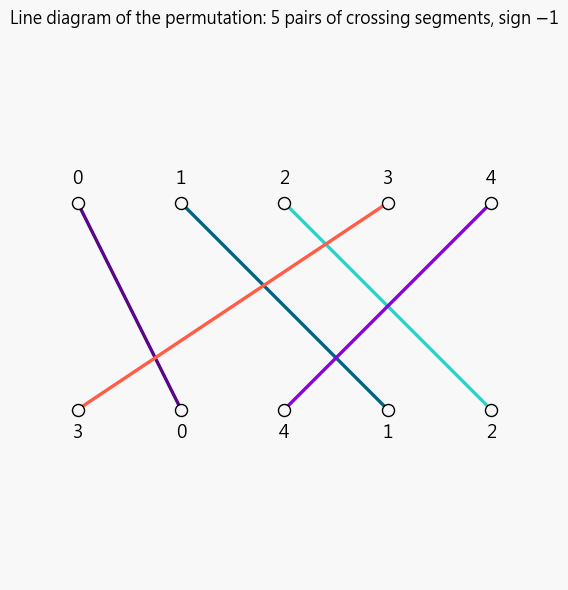

In [2]:
# ============================================================
print_header("Exercise 7-1 | Inversions and Crossings")
# ============================================================

# --- Step 1 ---
print_step(1, "Compute the number of inversions and the inverse permutation")
sigma=np.array([3,0,4,1,2]); inverse=np.argsort(sigma)
check("number of inversions", inversion_count(sigma), 5)
check("sgn(σ)", permutation_sign(sigma), -1)
check("pairs of crossing segments", inversion_count(inverse), 5)
# --- Step 2 ---
print_step(2, "Draw the permutation diagram joining equal values in the two rows")
fig,ax=plt.subplots(figsize=(6,6),facecolor=C_BG)
ax.set_facecolor(C_BG)
ax.grid(True,color=C_GRID,linewidth=.8,alpha=.7)
colors=[C_V1,C_V2,C_T1,C_WARN,C_T2]
for value, bottom in enumerate(inverse):
    ax.plot([value,bottom],[2,0],color=colors[value],linewidth=2.4)
for position in range(5):
    ax.scatter([position,position],[2,0],s=75,color=C_BG,edgecolor=C_AXIS,zorder=3)
    ax.text(position,2.18,str(position),ha='center',color=C_AXIS,fontsize=13)
    ax.text(position,-.28,str(sigma[position]),ha='center',color=C_AXIS,fontsize=13)
ax.set_xlim(-.65,4.65); ax.set_ylim(-1.65,3.65)
ax.set_aspect('equal',adjustable='box'); ax.set_box_aspect(1)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Line diagram of the permutation: 5 pairs of crossing segments, sign −1',color=C_AXIS)
for spine in ax.spines.values():spine.set_visible(False)
plt.tight_layout(); plt.show()

::::{exercise} Computing Signs
:label: exer-ch7-permutation-signs

Find the sign of each of the following permutations on $\{0,1,2,3,4\}$:
1. $[4,1,2,3,0]$.
2. $[0,1,2,3,4]$.
3. $[1,0,2,4,3]$.
4. $[1,2,3,4,0]$.

**Hint.** For each position, count the images to its right that are smaller than its own image.

:::{solution} exer-ch7-permutation-signs
:class: dropdown

**Step 1.** The per-position inversion contributions of the four lists of images are $(4,1,1,1,0)$, $(0,0,0,0,0)$, $(1,0,0,1,0)$, and $(1,1,1,1,0)$, respectively, with totals $7,0,2,4$.

**Step 2.** Substituting into $\operatorname{sgn}(\sigma)=(-1)^{N(\sigma)}$, the answers are $\underline{-1,1,1,1}$, respectively.
:::
::::

In [3]:
# ============================================================
print_header("Exercise 7-2 | Computing Signs")
# ============================================================

# --- Step 1 ---
print_step(1, "Compare the numbers of inversions and the signs one by one")
for sigma,count in [([4,1,2,3,0],7),([0,1,2,3,4],0),([1,0,2,4,3],2),([1,2,3,4,0],4)]:
    check("number of inversions", inversion_count(sigma), count)
    check("sign", permutation_sign(sigma), (-1)**count)

  Exercise 7-2 | Computing Signs

▶ Step 1: Compare the numbers of inversions and the signs one by one
----------------------------------------

[number of inversions]
  Computed value: 7
  Expected value: 7
  check passed

[sign]
  Computed value: -1
  Expected value: -1
  check passed

[number of inversions]
  Computed value: 0
  Expected value: 0
  check passed

[sign]
  Computed value: 1
  Expected value: 1
  check passed

[number of inversions]
  Computed value: 2
  Expected value: 2
  check passed

[sign]
  Computed value: 1
  Expected value: 1
  check passed

[number of inversions]
  Computed value: 4
  Expected value: 4
  check passed

[sign]
  Computed value: 1
  Expected value: 1
  check passed


::::{exercise} Signs of Compositions
:label: exer-ch7-composition-signs

Use the following three examples to test $\operatorname{sgn}(\sigma\circ\tau)=\operatorname{sgn}(\sigma)\operatorname{sgn}(\tau)$ (in the composition, $\tau$ acts first):
1. $\sigma=[1,4,3,2,0]$, $\tau=[0,1,2,3,4]$.
2. $\sigma=[2,3,4,0,1]$, $\tau=[1,0,3,4,2]$.
3. $\sigma=[1,4,3,2,0]$, $\tau=[1,0,3,4,2]$.

**Hint.** The $i$-th image of the composition is $\sigma(\tau(i))$.

:::{solution} exer-ch7-composition-signs
:class: dropdown

**Step 1.** The lists of images of the three compositions are $[1,4,3,2,0]$, $[3,2,0,1,4]$, and $[4,1,2,0,3]$, respectively.

**Step 2.** The numbers of inversions $(N(\sigma),N(\tau),N(\sigma\circ\tau))$ of the three examples are $(7,0,7)$, $(6,3,5)$, and $(7,3,6)$, respectively. Hence the sign identities are $\underline{-1=(-1)(1)}$, $\underline{-1=(1)(-1)}$, and $\underline{1=(-1)(-1)}$, respectively, and all of them hold.

These examples are only checks; the general property can be proved with adjacent exchanges: each adjacent exchange changes the parity of the number of inversions, and any permutation can be sorted into the identity permutation by adjacent exchanges. When two sequences of exchanges are composed, the parities of the numbers of exchanges add, so the signs multiply.
:::
::::

In [4]:
# ============================================================
print_header("Exercise 7-3 | Signs of Compositions")
# ============================================================

# --- Step 1 ---
print_step(1, "Build the lists of images in the order of composition")
cases=[([1,4,3,2,0],[0,1,2,3,4],[1,4,3,2,0]),([2,3,4,0,1],[1,0,3,4,2],[3,2,0,1,4]),([1,4,3,2,0],[1,0,3,4,2],[4,1,2,0,3])]
for sigma,tau,expected in cases:
    comp=np.array(sigma)[tau]
    check("σ∘τ", comp, expected)
    check("sign of the composition", permutation_sign(comp), permutation_sign(sigma)*permutation_sign(tau))

  Exercise 7-3 | Signs of Compositions

▶ Step 1: Build the lists of images in the order of composition
----------------------------------------

[σ∘τ]
  Computed value: [1 4 3 2 0]
  Expected value: [1, 4, 3, 2, 0]
  check passed

[sign of the composition]
  Computed value: -1
  Expected value: -1
  check passed

[σ∘τ]
  Computed value: [3 2 0 1 4]
  Expected value: [3, 2, 0, 1, 4]
  check passed

[sign of the composition]
  Computed value: -1
  Expected value: -1
  check passed

[σ∘τ]
  Computed value: [4 1 2 0 3]
  Expected value: [4, 1, 2, 0, 3]
  check passed

[sign of the composition]
  Computed value: 1
  Expected value: 1
  check passed


::::{exercise} The Classical Expansion
:label: exer-ch7-leibniz-small-orders

The classical definition is $\det\mathbf{A}=\sum_{\sigma\in S_n}\operatorname{sgn}(\sigma)\prod_{i=0}^{n-1}a_{i,\sigma(i)}$.
1. Verify that for $n=2$ it is $a_{00}a_{11}-a_{01}a_{10}$.
2. List the six permutations in $S_3$ together with their signs, and use them to derive the formula for order three.

**Hint.** Each product takes exactly one entry from every row and every column. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-leibniz-small-orders
:class: dropdown

1. The lists of images $[0,1]$ and $[1,0]$ in $S_2$ have signs $1,-1$, respectively, so the formula for order two is exactly $a_{00}a_{11}-a_{01}a_{10}$.
2. The even permutations of order three are $[0,1,2],[1,2,0],[2,0,1]$, with numbers of inversions $0,2,2$; the odd permutations are $[0,2,1],[1,0,2],[2,1,0]$, with numbers of inversions $1,1,3$. Therefore
   $$\det\mathbf{A}=a_{00}a_{11}a_{22}+a_{01}a_{12}a_{20}+a_{02}a_{10}a_{21}-a_{00}a_{12}a_{21}-a_{01}a_{10}a_{22}-a_{02}a_{11}a_{20}.$$
   The six terms correspond to the six permutations above, and there are no other terms. $\square$
:::
::::

::::{exercise} A Sparse Expansion
:label: exer-ch7-sparse-leibniz

Use the classical definition to compute the determinant of
$$\mathbf{A}=\begin{pmatrix}0&2&0&5\\1&0&0&3\\2&0&4&0\\0&5&0&6\end{pmatrix}$$

**Hint.** First note that the only nonzero entry of column 2 must be chosen.

:::{solution} exer-ch7-sparse-leibniz
:class: dropdown

**Step 1.** Column 2 has only one nonzero entry, $a_{22}=4$, so every nonzero term must have $\sigma(2)=2$; among the remaining rows, only row 1 can still supply column 0, so $\sigma(1)=0$. The remaining images $1,3$ are assigned to rows 0 and 3.

**Step 2.** Only the two terms $[1,0,2,3]$ and $[3,0,2,1]$ are nonzero, with numbers of inversions $1,4$, respectively, so
$$\underline{\det\mathbf{A}=-(2)(1)(4)(6)+(5)(1)(4)(5)=-48+100=52}.$$
:::
::::

In [5]:
# ============================================================
print_header("Exercise 7-5 | A Sparse Expansion")
# ============================================================

# --- Step 1 ---
print_step(1, "List the nonzero terms of the classical definition")
A=np.array([[0,2,0,5],[1,0,0,3],[2,0,4,0],[0,5,0,6]])
terms=[]
for sigma in permutations(range(4)):
    term=permutation_sign(sigma)*np.prod(A[np.arange(4),sigma])
    if term:
        print(f"σ={sigma}: {term}"); terms.append(term)
check("nonzero terms", sorted(terms), [-48,100])
check("determinant", np.linalg.det(A), 52)

  Exercise 7-5 | A Sparse Expansion

▶ Step 1: List the nonzero terms of the classical definition
----------------------------------------
σ=(1, 0, 2, 3): -48
σ=(3, 0, 2, 1): 100

[nonzero terms]
  Computed value: [np.int64(-48), np.int64(100)]
  Expected value: [-48, 100]
  check passed

[determinant]
  Computed value: 51.999999999999986
  Expected value: 52
  check passed


::::{exercise} The Reversal Matrix
:label: exer-ch7-identity-reversal

Find the determinants of the $n\times n$ identity matrix $\mathbf{I}_n$ and of the reversal matrix $\mathbf{P}$ ($p_{i,n-1-i}=1$, all other entries $0$).

**Hint.** The reversal permutation makes every pair of indices an inversion.

:::{solution} exer-ch7-identity-reversal
:class: dropdown

**Step 1.** By the definition of the identity matrix, only the term of the identity permutation is nonzero, and both its product and its sign are $1$, so $\underline{\det\mathbf{I}_n=1}$.

**Step 2.** The only nonzero term of the reversal matrix is $\sigma(i)=n-1-i$. Every pair $i<j$ is an inversion, $n(n-1)/2$ pairs in all, so $\underline{\det\mathbf{P}=(-1)^{n(n-1)/2}}$; this equals $1$ when $n\equiv0,1\pmod4$ and $-1$ when $n\equiv2,3\pmod4$.
:::
::::

In [6]:
# ============================================================
print_header("Exercise 7-6 | The Reversal Matrix")
# ============================================================

# --- Step 1 ---
print_step(1, "Check the identity and reversal matrices of each order")
for n in range(1,9):
    check(f"det(I_{n})", np.linalg.det(np.eye(n)), 1)
    check(f"reversal matrix n={n}", np.linalg.det(np.eye(n)[::-1]), (-1)**(n*(n-1)//2))

  Exercise 7-6 | The Reversal Matrix

▶ Step 1: Check the identity and reversal matrices of each order
----------------------------------------

[det(I_1)]
  Computed value: 1.0
  Expected value: 1
  check passed

[reversal matrix n=1]
  Computed value: 1.0
  Expected value: 1
  check passed

[det(I_2)]
  Computed value: 1.0
  Expected value: 1
  check passed

[reversal matrix n=2]
  Computed value: -1.0
  Expected value: -1
  check passed

[det(I_3)]
  Computed value: 1.0
  Expected value: 1
  check passed

[reversal matrix n=3]
  Computed value: -1.0
  Expected value: -1
  check passed

[det(I_4)]
  Computed value: 1.0
  Expected value: 1
  check passed

[reversal matrix n=4]
  Computed value: 1.0
  Expected value: 1
  check passed

[det(I_5)]
  Computed value: 1.0
  Expected value: 1
  check passed

[reversal matrix n=5]
  Computed value: 1.0
  Expected value: 1
  check passed

[det(I_6)]
  Computed value: 1.0
  Expected value: 1
  check passed

[reversal matrix n=6]
  Computed valu

::::{exercise} Triangular Determinants
:label: exer-ch7-triangular-determinants

Prove that the determinant of an $n\times n$ upper triangular matrix is $\prod_{i=0}^{n-1}a_{ii}$. Is the same true in the lower triangular case?

**Hint.** Any permutation other than the identity must pick up a zero outside the triangular region somewhere. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-triangular-determinants
:class: dropdown

1. For an upper triangular matrix, a nonzero product requires $\sigma(i)\ge i$ for all $i$. But $\sum_{i=0}^{n-1}\sigma(i)=\sum_{i=0}^{n-1}i$, so every one of these inequalities must be an equality; that is, $\sigma$ is the identity permutation.
2. Hence all other terms are zero, and the determinant equals the term of the identity permutation, $\prod_{i=0}^{n-1}a_{ii}$; this formula holds even if some diagonal entry is zero.
3. The lower triangular case requires $\sigma(i)\le i$, and the equality of the sums again forces $\sigma(i)=i$, so the determinant is again the product of the diagonal entries. $\square$
:::
::::

::::{exercise} Determinants of Permutation Matrices
:label: exer-ch7-permutation-determinants

Use the definition $(\mathbf{P}_\sigma)_{ij}=1$ if and only if $j=\sigma(i)$.
1. Prove that $\det\mathbf{P}_\sigma=\operatorname{sgn}(\sigma)$.
2. Using the composition property of the sign of a permutation, verify that $\det(\mathbf{P}_\sigma\mathbf{P}_\tau)=\det\mathbf{P}_\sigma\det\mathbf{P}_\tau$.

**Hint.** Under this convention, $\mathbf{P}_\sigma\mathbf{P}_\tau=\mathbf{P}_{\tau\circ\sigma}$. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-permutation-determinants
:class: dropdown

1. In the classical expansion, for every factor to be nonzero, row $i$ must take column $\sigma(i)$. Hence only the term of the permutation $\sigma$ is nonzero; the product of its entries is $1$, and its sign is $\operatorname{sgn}(\sigma)$.
2. Multiplying out the entries gives $\mathbf{P}_\sigma\mathbf{P}_\tau=\mathbf{P}_{\tau\circ\sigma}$. Therefore
   $$\det(\mathbf{P}_\sigma\mathbf{P}_\tau)=\operatorname{sgn}(\tau\circ\sigma)=\operatorname{sgn}(\tau)\operatorname{sgn}(\sigma)=\det\mathbf{P}_\sigma\det\mathbf{P}_\tau.$$
   Only the multiplicativity of the sign of permutations is used here; there is no need to invoke in advance the product theorem for determinants of general matrices. $\square$
:::
::::

### Basic Properties and Computation by Elimination

::::{exercise} Basic Properties
:label: exer-ch7-determinant-axioms-three

Regard a determinant of order three as a function of its three row vectors, write out the classical six-term formula, and verify:
1. $\det\mathbf{I}_3=1$.
2. With the other rows fixed, it is linear in any one row with respect to both addition and scalar multiplication.
3. Exchanging any two rows changes the sign of the determinant.

**Hint.** Each term contains exactly one entry from every row, and exchanging rows rearranges the permutation indices. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-determinant-axioms-three
:class: dropdown

1. The six-term formula is
   $$a_{00}a_{11}a_{22}+a_{01}a_{12}a_{20}+a_{02}a_{10}a_{21}-a_{00}a_{12}a_{21}-a_{01}a_{10}a_{22}-a_{02}a_{11}a_{20}.$$
   Substituting $\mathbf{I}_3$, only the first term equals $1$ and all the others are zero, so normalization holds.
2. With the other two rows fixed, each term is one entry of the chosen row times a coefficient that does not depend on that row; hence, replacing that row with $\alpha\mathbf{u}^\top+\beta\mathbf{v}^\top$ and expanding gives $\alpha\det(\ldots,\mathbf{u}^\top,\ldots)+\beta\det(\ldots,\mathbf{v}^\top,\ldots)$, which covers both additivity and homogeneity.
3. Exchanging any two rows amounts to re-pairing the six permutation terms by a transposition. A transposition is an odd permutation, so after the re-pairing each term has the same product but the opposite sign, and the whole determinant changes sign. $\square$
:::
::::

::::{exercise} Computation by Elimination
:label: exer-ch7-elimination-determinants

Use row operations to find the determinants of the following matrices:
$$\mathbf{A}=\begin{pmatrix}1&2&3&4\\2&3&4&1\\3&4&1&2\\4&1&2&3\end{pmatrix}, 
\mathbf{B}=\begin{pmatrix}3&1&1&1\\2&3&4&1\\1&1&2&1\\2&-1&-1&1\end{pmatrix}, 
\mathbf{C}=\begin{pmatrix}1&0&2&3\\0&1&1&2\\4&3&1&0\\2&1&0&1\end{pmatrix}.$$

**Hint.** If you only add multiples of one row to another, you can read off the determinant directly as the product of the final diagonal entries.

:::{solution} exer-ch7-elimination-determinants
:class: dropdown

**Step 1.** For $\mathbf{A}$, eliminate below the pivot in column 0 with multipliers $2,3,4$, then below the pivot in column 1 with multipliers $2,7$, and finally below the pivot in column 2 with multiplier $-1$, obtaining
$$\mathbf{U}_A=\begin{pmatrix}1&2&3&4\\0&-1&-2&-7\\0&0&-4&4\\0&0&0&40\end{pmatrix}.$$
Hence $\underline{\det\mathbf{A}=160}$.

**Step 2.** For $\mathbf{B}$, the multipliers of the three rounds of elimination are $(2/3,1/3,2/3)$, $(2/7,-5/7)$, and $1$, respectively, giving
$$\mathbf{U}_B=\begin{pmatrix}3&1&1&1\\0&7/3&10/3&1/3\\0&0&5/7&4/7\\0&0&0&0\end{pmatrix}.$$
Hence $\underline{\det\mathbf{B}=0}$.

**Step 3.** For $\mathbf{C}$, first use the first two rows to eliminate the lower-left $2\times2$ block, which leaves the lower-right block $\begin{pmatrix}-10&-18\\-5&-7\end{pmatrix}$. Then perform $R_3\leftarrow R_3-R_2/2$; the last two diagonal entries are $-10,2$, so $\underline{\det\mathbf{C}=-20}$. All of these operations preserve the determinant.
:::
::::

In [7]:
# ============================================================
print_header("Exercise 7-10 | Computation by Elimination")
# ============================================================

# --- Step 1 ---
print_step(1, "Cross-check the diagonal after elimination against the NumPy determinant")
cases=[([[1,2,3,4],[2,3,4,1],[3,4,1,2],[4,1,2,3]],160),([[3,1,1,1],[2,3,4,1],[1,1,2,1],[2,-1,-1,1]],0),([[1,0,2,3],[0,1,1,2],[4,3,1,0],[2,1,0,1]],-20)]
for A,expected in cases:
    L,U=lu_no_pivot(A)
    check("LU reconstruction", L@U, A)
    check("product of the diagonal of U", np.prod(np.diag(U)), expected)
    check("det(A)", np.linalg.det(A), expected)

  Exercise 7-10 | Computation by Elimination

▶ Step 1: Cross-check the diagonal after elimination against the NumPy determinant
----------------------------------------

[LU reconstruction]
  Computed value: [[1. 2. 3. 4.]
 [2. 3. 4. 1.]
 [3. 4. 1. 2.]
 [4. 1. 2. 3.]]
  Expected value: [[1, 2, 3, 4], [2, 3, 4, 1], [3, 4, 1, 2], [4, 1, 2, 3]]
  check passed

[product of the diagonal of U]
  Computed value: 160.0
  Expected value: 160
  check passed

[det(A)]
  Computed value: 160.00000000000009
  Expected value: 160
  check passed

[LU reconstruction]
  Computed value: [[ 3.  1.  1.  1.]
 [ 2.  3.  4.  1.]
 [ 1.  1.  2.  1.]
 [ 2. -1. -1.  1.]]
  Expected value: [[3, 1, 1, 1], [2, 3, 4, 1], [1, 1, 2, 1], [2, -1, -1, 1]]
  check passed

[product of the diagonal of U]
  Computed value: -1.1102230246251563e-15
  Expected value: 0
  check passed

[det(A)]
  Computed value: 0.0
  Expected value: 0
  check passed

[LU reconstruction]
  Computed value: [[1. 0. 2. 3.]
 [0. 1. 1. 2.]
 [4. 3. 1.

::::{exercise} Elementary Matrices
:label: exer-ch7-elementary-determinants

For $n\times n$ elementary matrices ($i\ne j$), prove:
1. The matrix $\mathbf{R}_{ij}(c)$ that adds $c$ times row $i$ to row $j$ has determinant $1$.
2. The matrix $\mathbf{R}_i(c)$ that multiplies row $i$ by $c$ has determinant $c$.
3. The matrix $\mathbf{P}_{ij}$ that exchanges rows $i,j$ has determinant $-1$.

For a scaling to count as an elementary row operation we need $c\ne0$, but the determinant identity still holds when $c=0$.

**Hint.** Apply the operations to the identity matrix, and use multilinearity and antisymmetry under exchange. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-elementary-determinants
:class: dropdown

1. $\mathbf{R}_{ij}(c)=\mathbf{I}_n+c\mathbf{e}_j\mathbf{e}_i^\top$. Expanding by linearity in row $j$, the first term is $\det\mathbf{I}_n=1$, and the second term contains two identical standard basis rows, so it is zero; the total is $1$.
2. After the scaling, the matrix is diagonal, with every diagonal entry equal to $1$ except the $i$-th, which is $c$, so its determinant is $c$.
3. Exchanging two rows of the identity matrix changes the sign of the determinant, so $\det\mathbf{P}_{ij}=-1$. $\square$
:::
::::

::::{exercise} Row Operations and Multiplication
:label: exer-ch7-row-operation-determinants

For an $n\times n$ matrix $\mathbf{A}$, prove:
1. $\det(\mathbf{R}_{ij}(c)\mathbf{A})=\det\mathbf{A}=\det\mathbf{R}_{ij}(c)\det\mathbf{A}$.
2. $\det(\mathbf{R}_i(c)\mathbf{A})=c\det\mathbf{A}=\det\mathbf{R}_i(c)\det\mathbf{A}$.
3. $\det(\mathbf{P}_{ij}\mathbf{A})=-\det\mathbf{A}=\det\mathbf{P}_{ij}\det\mathbf{A}$.

**Hint.** There is no need to use the general product theorem first; simply apply multilinearity in the rows directly. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-row-operation-determinants
:class: dropdown

1. Row $j$ becomes the original row $j$ plus $c$ times the original row $i$. Splitting by multilinearity, the term other than the original determinant has two identical rows, so it is zero; then $\det\mathbf{R}_{ij}(c)=1$ gives the second equality.
2. Row $i$ is scaled by a factor of $c$, so linearity in that row lets us factor out $c$; then $\det\mathbf{R}_i(c)=c$ gives the desired equality.
3. Exchanging two rows changes the sign by antisymmetry; moreover $\det\mathbf{P}_{ij}=-1$, so all the equalities hold. $\square$
:::
::::

::::{exercise} Effect of a Row Permutation
:label: exer-ch7-row-permutation-sign

For an $n\times n$ matrix $\mathbf{A}$ and $\sigma\in S_n$, prove that
$$\det(\mathbf{P}_\sigma\mathbf{A})=\operatorname{sgn}(\sigma)\det\mathbf{A}=\det\mathbf{P}_\sigma\det\mathbf{A}.$$

**Hint.** Use adjacent exchanges to restore the rows to their original order. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-row-permutation-sign
:class: dropdown

1. Row $i$ of $\mathbf{P}_\sigma\mathbf{A}$ is row $\sigma(i)$ of $\mathbf{A}$. When this order of rows is sorted by adjacent exchanges, each exchange removes exactly one inversion, so the original order can be restored with $N(\sigma)$ adjacent exchanges in all.
2. Each exchange multiplies the determinant by $-1$, so $\det\mathbf{A}=(-1)^{N(\sigma)}\det(\mathbf{P}_\sigma\mathbf{A})$. Since the square of a sign is $1$, rearranging gives the first equality.
3. We have already shown that $\det\mathbf{P}_\sigma=(-1)^{N(\sigma)}$, so the second equality also holds; this derivation includes the case in which $\mathbf{A}$ is singular. $\square$
:::
::::

::::{exercise} Recording the Operations
:label: exer-ch7-record-elimination

Let $\mathbf{A}=\begin{pmatrix}0&0&-1&4\\2&4&6&0\\1&2&1&1\\2&0&1&3\end{pmatrix}$.
1. Find the determinant using row operations.
2. Record each elementary matrix, and write the ref in the form $\mathbf{E}_{k-1}\cdots\mathbf{E}_0\mathbf{A}=\mathbf{U}$.
3. Find $\det\mathbf{U}$.
4. Verify that $\det\mathbf{A}=(\prod_{i=0}^{k-1}\det\mathbf{E}_i^{-1})\det\mathbf{U}$.

**Hint.** The work can be arranged with two row exchanges, whose minus signs cancel.

:::{solution} exer-ch7-record-elimination
:class: dropdown

**Step 1.** Record the five operations in order: exchange $R_0,R_2$; $R_1\leftarrow R_1-2R_0$; $R_3\leftarrow R_3-2R_0$; exchange $R_1,R_3$; $R_3\leftarrow R_3+4R_2$.

**Step 2.** Let $\mathbf{P}_{ij}$ denote an exchange matrix. The five matrices are
$$\mathbf{E}_0=\mathbf{P}_{02},  \mathbf{E}_1=\mathbf{I}_4-2\mathbf{e}_1\mathbf{e}_0^\top, 
\mathbf{E}_2=\mathbf{I}_4-2\mathbf{e}_3\mathbf{e}_0^\top, 
\mathbf{E}_3=\mathbf{P}_{13},  \mathbf{E}_4=\mathbf{I}_4+4\mathbf{e}_3\mathbf{e}_2^\top.$$
Multiplying on the left in this order, they produce
$$\underline{\mathbf{U}=\begin{pmatrix}1&2&1&1\\0&-4&-1&1\\0&0&-1&4\\0&0&0&14\end{pmatrix}}.$$
**Step 3.** $\det\mathbf{U}=1(-4)(-1)(14)=56$. The determinants of the five operations, and likewise of their inverses, are $-1,1,1,-1,1$ in order, with product $1$, so
$$\underline{\det\mathbf{A}=(-1)(1)(1)(-1)(1)\det\mathbf{U}=56}.$$
The inverse matrices undo the operations in reverse order, so $\mathbf{A}=\mathbf{E}_0^{-1}\cdots\mathbf{E}_4^{-1}\mathbf{U}$.
:::
::::

In [8]:
# ============================================================
print_header("Exercise 7-14 | Recording the Operations")
# ============================================================

# --- Step 1 ---
print_step(1, "Form the elementary matrices step by step and eliminate")
A=np.array([[0,0,-1,4],[2,4,6,0],[1,2,1,1],[2,0,1,3]],dtype=float)
E0=np.eye(4)[[2,1,0,3]]; E1=np.eye(4); E1[1,0]=-2
E2=np.eye(4); E2[3,0]=-2
E3=np.eye(4)[[0,3,2,1]]; E4=np.eye(4); E4[3,2]=4
U=A.copy(); det_factors=[]
for E in [E0,E1,E2,E3,E4]:
    U=E@U; det_factors.append(np.linalg.det(E))
check("U", U, [[1,2,1,1],[0,-4,-1,1],[0,0,-1,4],[0,0,0,14]])
# --- Step 2 ---
print_step(2, "Check the product of the determinants of the inverse operations")
check("det(U)", np.linalg.det(U), 56)
check("det(A)", np.linalg.det(U)/np.prod(det_factors), np.linalg.det(A))

  Exercise 7-14 | Recording the Operations

▶ Step 1: Form the elementary matrices step by step and eliminate
----------------------------------------

[U]
  Computed value: [[ 1.  2.  1.  1.]
 [ 0. -4. -1.  1.]
 [ 0.  0. -1.  4.]
 [ 0.  0.  0. 14.]]
  Expected value: [[1, 2, 1, 1], [0, -4, -1, 1], [0, 0, -1, 4], [0, 0, 0, 14]]
  check passed

▶ Step 2: Check the product of the determinants of the inverse operations
----------------------------------------

[det(U)]
  Computed value: 55.99999999999997
  Expected value: 56
  check passed

[det(A)]
  Computed value: 55.99999999999997
  Expected value: 56.00000000000002
  check passed


::::{exercise} Factorizations and Determinants
:label: exer-ch7-factorization-determinants

Prove:
1. Every unit lower triangular matrix $\mathbf{L}$ can be written as $\mathbf{L}=\mathbf{R}_0\mathbf{R}_1\cdots\mathbf{R}_{k-1}$, where each $\mathbf{R}_i$ is a row-operation matrix of type $\mathbf{R}_{ij}(c)$ (adding a multiple of one row to another row).
2. If $\mathbf{A}=\mathbf{L}\mathbf{U}$ with $\mathbf{L}$ unit lower triangular, then $\det\mathbf{A}=\det\mathbf{L}\det\mathbf{U}=\det\mathbf{U}$.
3. If $\mathbf{A}=\mathbf{P}_\sigma\mathbf{L}\mathbf{U}$, then $\det\mathbf{A}=\det\mathbf{P}_\sigma\det\mathbf{L}\det\mathbf{U}=\operatorname{sgn}(\sigma)\det\mathbf{U}$.
4. If $\mathbf{A}=\mathbf{L}\mathbf{D}\mathbf{U}$ with both triangular factors unit triangular, then $\det\mathbf{A}=\prod_{i=0}^{n-1}d_{ii}$.

**Hint.** A unit triangular matrix can be reduced to the identity matrix by row-addition operations alone. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-factorization-determinants
:class: dropdown

1. Starting from column 0, eliminate the entries below the diagonal in order; every pivot is $1$, so no row exchange or scaling is needed. Hence there are row-addition elementary matrices with $\mathbf{E}_{k-1}\cdots\mathbf{E}_0\mathbf{L}=\mathbf{I}_n$, and so $\mathbf{L}=\mathbf{E}_0^{-1}\cdots\mathbf{E}_{k-1}^{-1}$. Each inverse is again a row-addition elementary matrix; one only needs to change the sign of the multiplier.
2. Multiplying on the left by the factors above preserves the determinant, so $\det(\mathbf{L}\mathbf{U})=\det\mathbf{U}$. Moreover $\det\mathbf{L}=1$, which gives the claim.
3. Using in addition the sign property of row permutations, we obtain $\det(\mathbf{P}_\sigma\mathbf{L}\mathbf{U})=\operatorname{sgn}(\sigma)\det\mathbf{U}$.
4. $\mathbf{D}\mathbf{U}$ is an upper triangular matrix with diagonal entries $d_{ii}$, so by item 2 and the triangular formula, $\det\mathbf{A}=\det(\mathbf{D}\mathbf{U})=\prod_{i=0}^{n-1}d_{ii}$, even if some diagonal entry is zero. $\square$
:::
::::

### Block Determinants

::::{exercise} Block Formulas
:label: exer-ch7-block-determinant-identities

Prove the following block determinant formulas, where the block sizes are such that all products are defined:
1. If $\mathbf{A},\mathbf{C}$ are square matrices of orders $p,q$, respectively, then $\det\begin{pmatrix}\mathbf{A}&\mathbf{0}\\\mathbf{B}&\mathbf{C}\end{pmatrix}=\det\mathbf{A}\det\mathbf{C}$.
2. $\det\begin{pmatrix}\mathbf{I}_p&\mathbf{B}\\\mathbf{C}&\mathbf{I}_q\end{pmatrix}=\det(\mathbf{I}_q-\mathbf{C}\mathbf{B})=\det(\mathbf{I}_p-\mathbf{B}\mathbf{C})$.
3. If $\mathbf{D}$ is an invertible matrix of order $q$, then $\det\begin{pmatrix}\mathbf{I}_p&\mathbf{B}\\\mathbf{C}&\mathbf{D}\end{pmatrix}=\det(\mathbf{D}-\mathbf{C}\mathbf{B})=\det\mathbf{D}\det(\mathbf{I}_p-\mathbf{B}\mathbf{D}^{-1}\mathbf{C})$.
4. For blocks of order $n$, $\det\begin{pmatrix}\mathbf{A}&\mathbf{I}_n\\\mathbf{C}&\mathbf{D}\end{pmatrix}=(-1)^n\det(\mathbf{C}-\mathbf{D}\mathbf{A})$.

**Hint.** A block row-addition operation can be decomposed into ordinary row-addition operations, which do not change the determinant. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-block-determinant-identities
:class: dropdown

1. By the classical expansion, a nonzero term must match the first $p$ rows with the first $p$ columns; otherwise it would pick up an entry of the upper-right zero block. The remaining last $q$ rows can then be matched only with the last $q$ columns. There are no cross-block inversions between the two groups of permutations, so the signs and the products separate, and the double sum is exactly $\det\mathbf{A}\det\mathbf{C}$; no invertibility assumption is needed.
2. Subtracting $\mathbf{C}$ times the top block row from the bottom block row gives $\begin{pmatrix}\mathbf{I}_p&\mathbf{B}\\\mathbf{0}&\mathbf{I}_q-\mathbf{C}\mathbf{B}\end{pmatrix}$, whose determinant is the first expression. If instead $\mathbf{B}$ times the bottom block row is subtracted from the top block row, we obtain $\begin{pmatrix}\mathbf{I}_p-\mathbf{B}\mathbf{C}&\mathbf{0}\\\mathbf{C}&\mathbf{I}_q\end{pmatrix}$, which gives the other expression.
3. As before, eliminating the lower-left block first gives $\det(\mathbf{D}-\mathbf{C}\mathbf{B})$. In the other direction, subtracting $\mathbf{B}\mathbf{D}^{-1}$ times the bottom block row from the top block row gives the upper-left block $\mathbf{I}_p-\mathbf{B}\mathbf{D}^{-1}\mathbf{C}$ and a zero upper-right block, and item 1 gives the second formula.
4. First exchange the two groups of $n$ columns each; altogether this is equivalent to $n^2$ single column exchanges, with sign $(-1)^{n^2}=(-1)^n$. The resulting matrix is $\begin{pmatrix}\mathbf{I}_n&\mathbf{A}\\\mathbf{D}&\mathbf{C}\end{pmatrix}$; after the lower-left block is eliminated, its determinant is $\det(\mathbf{C}-\mathbf{D}\mathbf{A})$. Hence the determinant of the original matrix is given by the stated formula. $\square$
:::
::::

::::{exercise} Block Computations
:label: exer-ch7-block-determinant-examples

Use the block formulas to find:
$$\mathbf{M}_0=\begin{pmatrix}2&3&0&0\\1&4&0&0\\5&-1&3&1\\2&6&1&2\end{pmatrix}, 
\mathbf{M}_1=\begin{pmatrix}3&1&1&0\\1&0&0&1\\1&1&2&1\\2&-1&-1&1\end{pmatrix}, 
\mathbf{M}_2=\begin{pmatrix}1&0&2&3\\0&1&1&2\\4&3&1&0\\2&1&0&1\end{pmatrix}.$$

**Hint.** Use, in order, the formulas for a block lower triangular matrix, for an identity block in the upper right, and for an identity block in the upper left.

:::{solution} exer-ch7-block-determinant-examples
:class: dropdown

**Step 1.** $\mathbf{M}_0$ is block lower triangular, so $\underline{\det\mathbf{M}_0=(8-3)(6-1)=25}$.

**Step 2.** $\mathbf{M}_1=\begin{pmatrix}\mathbf{A}&\mathbf{I}_2\\\mathbf{C}&\mathbf{D}\end{pmatrix}$, and a computation gives $\mathbf{C}-\mathbf{D}\mathbf{A}=\begin{pmatrix}-6&-1\\4&0\end{pmatrix}$, so $\underline{\det\mathbf{M}_1=(-1)^2(4)=4}$.

**Step 3.** $\mathbf{M}_2=\begin{pmatrix}\mathbf{I}_2&\mathbf{B}\\\mathbf{C}&\mathbf{D}\end{pmatrix}$ and $\mathbf{D}-\mathbf{C}\mathbf{B}=\begin{pmatrix}-10&-18\\-5&-7\end{pmatrix}$, so $\underline{\det\mathbf{M}_2=70-90=-20}$.
:::
::::

In [9]:
# ============================================================
print_header("Exercise 7-17 | Block Computations")
# ============================================================

# --- Step 1 ---
print_step(1, "Check the three block reductions")
M0=np.array([[2,3,0,0],[1,4,0,0],[5,-1,3,1],[2,6,1,2]])
M1=np.array([[3,1,1,0],[1,0,0,1],[1,1,2,1],[2,-1,-1,1]])
M2=np.array([[1,0,2,3],[0,1,1,2],[4,3,1,0],[2,1,0,1]])
check("block lower triangular", np.linalg.det(M0[:2,:2])*np.linalg.det(M0[2:,2:]), 25)
check("C-DA", M1[2:,:2]-M1[2:,2:]@M1[:2,:2], [[-6,-1],[4,0]])
check("D-CB", M2[2:,2:]-M2[2:,:2]@M2[:2,2:], [[-10,-18],[-5,-7]])
for M,expected in [(M0,25),(M1,4),(M2,-20)]:check("det(M)", np.linalg.det(M), expected)

  Exercise 7-17 | Block Computations

▶ Step 1: Check the three block reductions
----------------------------------------

[block lower triangular]
  Computed value: 25.00000000000001
  Expected value: 25
  check passed

[C-DA]
  Computed value: [[-6 -1]
 [ 4  0]]
  Expected value: [[-6, -1], [4, 0]]
  check passed

[D-CB]
  Computed value: [[-10 -18]
 [ -5  -7]]
  Expected value: [[-10, -18], [-5, -7]]
  check passed

[det(M)]
  Computed value: 25.000000000000007
  Expected value: 25
  check passed

[det(M)]
  Computed value: 4.000000000000001
  Expected value: 4
  check passed

[det(M)]
  Computed value: -20.000000000000007
  Expected value: -20
  check passed


::::{exercise} Computing with the Schur Complement
:label: exer-ch7-schur-complement-examples

When $\mathbf{M}=\begin{pmatrix}\mathbf{A}&\mathbf{B}\\\mathbf{C}&\mathbf{D}\end{pmatrix}$ and $\mathbf{A}$ is invertible, $\det\mathbf{M}=\det\mathbf{A}\det(\mathbf{D}-\mathbf{C}\mathbf{A}^{-1}\mathbf{B})$. Use this formula to find:
$$\mathbf{M}_0=\begin{pmatrix}1&2&3&4\\2&3&4&1\\3&4&1&2\\4&1&2&3\end{pmatrix}, 
\mathbf{M}_1=\begin{pmatrix}3&1&1&1\\2&3&4&1\\1&1&2&1\\2&-1&-1&1\end{pmatrix}, 
\mathbf{M}_2=\begin{pmatrix}0&5&0&2\\0&3&1&0\\2&0&4&0\\0&5&0&6\end{pmatrix}.$$

**Hint.** For $\mathbf{M}_2$ the upper-left $2\times2$ block cannot be inverted directly; exchange rows first.

:::{solution} exer-ch7-schur-complement-examples
:class: dropdown

**Step 1.** The upper-left block of $\mathbf{M}_0$ has determinant $-1$, and the Schur complement is $\begin{pmatrix}-4&4\\4&36\end{pmatrix}$, whose determinant is $-160$, so $\underline{\det\mathbf{M}_0=160}$.

**Step 2.** The upper-left block of $\mathbf{M}_1$ has determinant $7$, and the Schur complement is $\begin{pmatrix}5/7&4/7\\5/7&4/7\end{pmatrix}$, so $\underline{\det\mathbf{M}_1=0}$.

**Step 3.** The original upper-left block of $\mathbf{M}_2$ is singular, so first exchange rows 1 and 2 to obtain $\mathbf{N}$. The upper-left block $\begin{pmatrix}0&5\\2&0\end{pmatrix}$ now has determinant $-10$, and the Schur complement is $\begin{pmatrix}1&-6/5\\0&4\end{pmatrix}$. Hence $\det\mathbf{N}=-40$, and restoring the sign of the exchange gives $\underline{\det\mathbf{M}_2=40}$.
:::
::::

In [10]:
# ============================================================
print_header("Exercise 7-18 | Computing with the Schur Complement")
# ============================================================

# --- Step 1 ---
print_step(1, "Compute the Schur complement with solve, avoiding an explicit inverse")
cases=[([[1,2,3,4],[2,3,4,1],[3,4,1,2],[4,1,2,3]],160,False),([[3,1,1,1],[2,3,4,1],[1,1,2,1],[2,-1,-1,1]],0,False),([[0,5,0,2],[0,3,1,0],[2,0,4,0],[0,5,0,6]],40,True)]
for values,expected,swap in cases:
    M=np.array(values,dtype=float); N=M[[0,2,1,3]] if swap else M
    A,B,C,D=N[:2,:2],N[:2,2:],N[2:,:2],N[2:,2:]
    S=D-C@np.linalg.solve(A,B)
    factor=-1 if swap else 1
    check("block formula", factor*np.linalg.det(A)*np.linalg.det(S), expected)
    check("direct determinant", np.linalg.det(M), expected)

  Exercise 7-18 | Computing with the Schur Complement

▶ Step 1: Compute the Schur complement with solve, avoiding an explicit inverse
----------------------------------------

[block formula]
  Computed value: 159.99999999999994
  Expected value: 160
  check passed

[direct determinant]
  Computed value: 160.00000000000009
  Expected value: 160
  check passed

[block formula]
  Computed value: -3.9650822308041406e-16
  Expected value: 0
  check passed

[direct determinant]
  Computed value: 0.0
  Expected value: 0
  check passed

[block formula]
  Computed value: 39.99999999999999
  Expected value: 40
  check passed

[direct determinant]
  Computed value: 39.99999999999998
  Expected value: 40
  check passed


### Properties of Determinants and Expansions

::::{exercise} Computing with Properties
:label: exer-ch7-determinant-property-calculations

Let $\mathbf{A},\mathbf{B}$ be $n\times n$ square matrices with $\det\mathbf{A}=3$ and $\det\mathbf{B}=-2$. Find:
1. $\det(2\mathbf{A})$.
2. $\det((\mathbf{A}^2)^\top(\mathbf{B}^\top)^2)$.
3. $\det(\mathbf{A}^{-1})$.
4. $\det(\mathbf{A}^{-1}\mathbf{B}\mathbf{A})$.

**Hint.** Multiplying the whole matrix by $2$ scales each of its $n$ rows by a factor of $2$.

:::{solution} exer-ch7-determinant-property-calculations
:class: dropdown

**Step 1.** Factoring the scalar out of each row gives $\underline{\det(2\mathbf{A})=3\cdot2^n}$; transposition does not change the determinant, and the determinant of a product is the product of the determinants, so item 2 is $\underline{3^2(-2)^2=36}$.

**Step 2.** Since $\det\mathbf{A}=3\ne0$, invertibility is guaranteed by the hypothesis. From $\det\mathbf{I}_n=\det\mathbf{A}\det\mathbf{A}^{-1}$ we get $\underline{\det\mathbf{A}^{-1}=1/3}$; finally, $\underline{\det(\mathbf{A}^{-1}\mathbf{B}\mathbf{A})=(1/3)(-2)(3)=-2}$.
:::
::::

In [11]:
# ============================================================
print_header("Exercise 7-19 | Computing with Properties")
# ============================================================

# --- Step 1 ---
print_step(1, "Test the formulas with concrete matrices of several sizes")
for n in [1,2,4]:
    A=np.eye(n); A[0,0]=3
    B=np.eye(n); B[0,0]=-2
    check("det(2A)", np.linalg.det(2*A), 3*2**n)
    check("det((A²)^T(B^T)²)", np.linalg.det((A@A).T@B.T@B.T), 36)
    check("det(A^{-1})", np.linalg.det(np.linalg.inv(A)), 1/3)
    check("det(A^{-1}BA)", np.linalg.det(np.linalg.solve(A,B@A)), -2)

  Exercise 7-19 | Computing with Properties

▶ Step 1: Test the formulas with concrete matrices of several sizes
----------------------------------------

[det(2A)]
  Computed value: 6.0
  Expected value: 6
  check passed

[det((A²)^T(B^T)²)]
  Computed value: 36.0
  Expected value: 36
  check passed

[det(A^{-1})]
  Computed value: 0.3333333333333333
  Expected value: 0.3333333333333333
  check passed

[det(A^{-1}BA)]
  Computed value: -2.0
  Expected value: -2
  check passed

[det(2A)]
  Computed value: 12.0
  Expected value: 12
  check passed

[det((A²)^T(B^T)²)]
  Computed value: 36.0
  Expected value: 36
  check passed

[det(A^{-1})]
  Computed value: 0.3333333333333333
  Expected value: 0.3333333333333333
  check passed

[det(A^{-1}BA)]
  Computed value: -2.0
  Expected value: -2
  check passed

[det(2A)]
  Computed value: 48.00000000000001
  Expected value: 48
  check passed

[det((A²)^T(B^T)²)]
  Computed value: 36.0
  Expected value: 36
  check passed

[det(A^{-1})]
  Computed

::::{exercise} Properties of Column Operations
:label: exer-ch7-column-operations

1. For an $n\times n$ matrix $\mathbf{M}$, add $c$ times column $i$ to column $k$ ($i\ne k$) to obtain $\mathbf{M}'$. Use the fact that transposition does not change the determinant to prove that the two matrices have the same determinant.
2. Express this operation as multiplication on the right by a matrix, and prove the claim that way.
3. How do column scaling and the exchange of two columns change the determinant?
4. Do normalization, multilinearity, and antisymmetry of the determinant still hold when stated in terms of columns?
5. First perform one round of column operations and then one round of row operations to simplify $\mathbf{B}=\begin{pmatrix}1&1&1&1\\1&2&2&2\\1&2&3&3\\1&2&3&4\end{pmatrix}$, and find its determinant.

**Hint.** Transposition interchanges column operations and row operations; for the last matrix, take differences of adjacent columns from right to left.

:::{solution} exer-ch7-column-operations
:class: dropdown

1. After transposition, the operation becomes adding $c$ times row $i$ to row $k$, so $\det\mathbf{M}'=\det((\mathbf{M}')^\top)=\det(\mathbf{M}^\top)=\det\mathbf{M}$.
2. Let $\mathbf{E}=\mathbf{I}_n+c\mathbf{e}_i\mathbf{e}_k^\top$; then $\mathbf{M}'=\mathbf{M}\mathbf{E}$. Since $\det\mathbf{E}=1$, the multiplicative property also gives the result; after transposition, this becomes the left multiplication $\mathbf{E}^\top\mathbf{M}^\top$.
3. Multiplying a column by $c$ multiplies the determinant by $c$; exchanging two columns changes its sign. Transposing the corresponding row-operation matrix and multiplying on the right gives the column-operation matrix.
4. Normalization is unchanged; linearity in any one column and the sign change under the exchange of two columns both follow from the row versions by transposition. $\square$

**Step 1.** For item 5, perform $C_3\leftarrow C_3-C_2$, $C_2\leftarrow C_2-C_1$, $C_1\leftarrow C_1-C_0$ in turn, where $C_j$ denotes column $j$, obtaining
$$\begin{pmatrix}1&0&0&0\\1&1&0&0\\1&1&1&0\\1&1&1&1\end{pmatrix}.$$
**Step 2.** This is already unit lower triangular, so $\underline{\det\mathbf{B}=1}$. If we then perform $R_3\leftarrow R_3-R_2$, $R_2\leftarrow R_2-R_1$, $R_1\leftarrow R_1-R_0$ in turn, we obtain $\mathbf{I}_4$. Each round consists of three elementary operations.
:::
::::

In [12]:
# ============================================================
print_header("Exercise 7-20 | Properties of Column Operations")
# ============================================================

# --- Step 1 ---
print_step(1, "Take differences of adjacent columns from right to left")
B=np.array([[1,1,1,1],[1,2,2,2],[1,2,3,3],[1,2,3,4]],dtype=float)
M=B.copy()
for j in range(3,0,-1):M[:,j]-=M[:,j-1]
check("after column operations", M, np.tril(np.ones((4,4))))
# --- Step 2 ---
print_step(2, "Take differences of adjacent rows from bottom to top")
for i in range(3,0,-1):M[i]-=M[i-1]
check("after row operations", M, np.eye(4))
check("det(B)", np.linalg.det(B), 1)

  Exercise 7-20 | Properties of Column Operations

▶ Step 1: Take differences of adjacent columns from right to left
----------------------------------------

[after column operations]
  Computed value: [[1. 0. 0. 0.]
 [1. 1. 0. 0.]
 [1. 1. 1. 0.]
 [1. 1. 1. 1.]]
  Expected value: [[1. 0. 0. 0.]
 [1. 1. 0. 0.]
 [1. 1. 1. 0.]
 [1. 1. 1. 1.]]
  check passed

▶ Step 2: Take differences of adjacent rows from bottom to top
----------------------------------------

[after row operations]
  Computed value: [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
  Expected value: [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
  check passed

[det(B)]
  Computed value: 1.0
  Expected value: 1
  check passed


::::{exercise} Cofactor Expansion
:label: exer-ch7-sparse-cofactor-calculations

Choose any row or column and use Laplace (cofactor) expansion to find:
$$\mathbf{A}=\begin{pmatrix}0&0&0&4\\0&0&4&1\\0&4&1&2\\4&1&2&3\end{pmatrix}, 
\mathbf{B}=\begin{pmatrix}3&1&0&1\\0&0&4&0\\1&1&0&1\\2&-1&0&1\end{pmatrix}, 
\mathbf{C}=\begin{pmatrix}1&0&2&3\\3&0&6&0\\4&0&1&0\\2&-4&12&0\end{pmatrix}.$$

**Hint.** Choose the row or column with the fewest nonzero entries, and do not forget $(-1)^{i+j}$.

:::{solution} exer-ch7-sparse-cofactor-calculations
:class: dropdown

**Step 1.** For $\mathbf{A}$, expanding along row 0,
$$\det\mathbf{A}=-4\det\begin{pmatrix}0&0&4\\0&4&1\\4&1&2\end{pmatrix}=-4\left(4\det\begin{pmatrix}0&4\\4&1\end{pmatrix}\right)=\underline{256}.$$
**Step 2.** For $\mathbf{B}$, expanding along row 1,
$$\det\mathbf{B}=-4\det\begin{pmatrix}3&1&1\\1&1&1\\2&-1&1\end{pmatrix}=-4(6+1-3)=\underline{-16}.$$
**Step 3.** For $\mathbf{C}$, expand along column 3, and then along column 1 of the resulting matrix:
$$\det\mathbf{C}=-3\det\begin{pmatrix}3&0&6\\4&0&1\\2&-4&12\end{pmatrix}=-3\left(4\det\begin{pmatrix}3&6\\4&1\end{pmatrix}\right)=\underline{252}.$$
:::
::::

In [13]:
# ============================================================
print_header("Exercise 7-21 | Cofactor Expansion")
# ============================================================

# --- Step 1 ---
print_step(1, "Check the sparse cofactor expansions against direct computation")
cases=[([[0,0,0,4],[0,0,4,1],[0,4,1,2],[4,1,2,3]],0,256),([[3,1,0,1],[0,0,4,0],[1,1,0,1],[2,-1,0,1]],1,-16),([[1,0,2,3],[3,0,6,0],[4,0,1,0],[2,-4,12,0]],0,252)]
for values,row,expected in cases:
    A=np.array(values)
    result=sum(A[row,j]*cofactor(A,row,j) for j in range(4))
    check("expansion along a row", result, expected)
    check("direct determinant", np.linalg.det(A), expected)

  Exercise 7-21 | Cofactor Expansion

▶ Step 1: Check the sparse cofactor expansions against direct computation
----------------------------------------

[expansion along a row]
  Computed value: 255.99999999999991
  Expected value: 256
  check passed

[direct determinant]
  Computed value: 255.99999999999994
  Expected value: 256
  check passed

[expansion along a row]
  Computed value: -16.000000000000007
  Expected value: -16
  check passed

[direct determinant]
  Computed value: -16.000000000000007
  Expected value: -16
  check passed

[expansion along a row]
  Computed value: 251.99999999999994
  Expected value: 252
  check passed

[direct determinant]
  Computed value: 252.00000000000003
  Expected value: 252
  check passed


### Recurrences and Polynomials

::::{exercise} A Tridiagonal Recurrence
:label: exer-ch7-tridiagonal-two

Let $A_n$ be the determinant of the $n\times n$ tridiagonal matrix whose main diagonal entries are all $2$, whose superdiagonal and subdiagonal entries are all $1$, and whose other entries are zero.
1. Find $A_1,A_2,A_3$ and conjecture a general formula.
2. Expanding along row 0, prove that $A_n=2A_{n-1}-A_{n-2}$ ($n\ge3$).
3. Find the general formula and verify the conjecture.

**Hint.** Column 0 of the second minor submatrix has only one nonzero entry.

:::{solution} exer-ch7-tridiagonal-two
:class: dropdown

**Step 1.** $A_1=2$, $A_2=4-1=3$, $A_3=2\cdot3-2=4$; we conjecture that $A_n=n+1$.

**Proof of the recurrence and the general formula.**

1. Expanding along row 0, the first term is $2A_{n-1}$. The $(0,1)$ entry is $1$, with a negative sign; after the corresponding row and column are deleted, expanding along column 0 of what remains leaves only the leading $1$ times $A_{n-2}$. Hence $A_n=2A_{n-1}-A_{n-2}$.
2. Rearranging gives $A_n-A_{n-1}=A_{n-1}-A_{n-2}$, so all successive differences equal $A_2-A_1=1$. Therefore $A_n=2+(n-1)=n+1$. $\square$

**Step 2.** Hence $\underline{A_n=n+1}$, in agreement with the first three values.
:::
::::

In [14]:
# ============================================================
print_header("Exercise 7-22 | A Tridiagonal Recurrence")
# ============================================================

# --- Step 1 ---
print_step(1, "Compare the matrix determinants with the general formula")
for n in range(1,11):
    A=2*np.eye(n)+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1)
    check(f"A_{n}", np.linalg.det(A), n+1)

  Exercise 7-22 | A Tridiagonal Recurrence

▶ Step 1: Compare the matrix determinants with the general formula
----------------------------------------

[A_1]
  Computed value: 2.0
  Expected value: 2
  check passed

[A_2]
  Computed value: 2.9999999999999996
  Expected value: 3
  check passed

[A_3]
  Computed value: 4.0
  Expected value: 4
  check passed

[A_4]
  Computed value: 4.999999999999999
  Expected value: 5
  check passed

[A_5]
  Computed value: 6.0
  Expected value: 6
  check passed

[A_6]
  Computed value: 6.999999999999998
  Expected value: 7
  check passed

[A_7]
  Computed value: 7.999999999999998
  Expected value: 8
  check passed

[A_8]
  Computed value: 8.999999999999998
  Expected value: 9
  check passed

[A_9]
  Computed value: 9.999999999999998
  Expected value: 10
  check passed

[A_10]
  Computed value: 10.999999999999996
  Expected value: 11
  check passed


::::{exercise} A General Tridiagonal Formula
:label: exer-ch7-tridiagonal-three

Let $D_n$ be the determinant of the $n\times n$ tridiagonal matrix with main diagonal entries $3$, superdiagonal entries $2$, and subdiagonal entries $1$.
1. Find $D_1,D_2$.
2. Use Laplace expansion to prove that $D_n=3D_{n-1}-2D_{n-2}$ ($n\ge3$).
3. Find a general formula for $D_n$.

**Hint.** Let the successive difference be $K_n=D_n-D_{n-1}$; it forms a geometric sequence.

:::{solution} exer-ch7-tridiagonal-three
:class: dropdown

**Step 1.** $D_1=3$, $D_2=9-2=7$.

**Proof of the recurrence and the general formula.**

1. Expanding along row 0, the first term is $3D_{n-1}$; the other nonzero entry is $2$, with a negative sign, and expanding its minor submatrix along column 0 gives $D_{n-2}$, so $D_n=3D_{n-1}-2D_{n-2}$.
2. Hence $K_n=D_n-D_{n-1}=2(D_{n-1}-D_{n-2})=2K_{n-1}$. From $K_2=4$ we get $K_n=2^n$, so $D_n=3+\sum_{j=2}^{n}2^j=2^{n+1}-1$; the case $n=1$ holds directly. $\square$

**Step 2.** The general formula is $\underline{D_n=2^{n+1}-1}$.
:::
::::

In [15]:
# ============================================================
print_header("Exercise 7-23 | A General Tridiagonal Formula")
# ============================================================

# --- Step 1 ---
print_step(1, "Check the nonsymmetric tridiagonal matrices")
for n in range(1,11):
    A=3*np.eye(n)+2*np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1)
    check(f"D_{n}", np.linalg.det(A), 2**(n+1)-1)

  Exercise 7-23 | A General Tridiagonal Formula

▶ Step 1: Check the nonsymmetric tridiagonal matrices
----------------------------------------

[D_1]
  Computed value: 3.0000000000000004
  Expected value: 3
  check passed

[D_2]
  Computed value: 7.000000000000001
  Expected value: 7
  check passed

[D_3]
  Computed value: 15.0
  Expected value: 15
  check passed

[D_4]
  Computed value: 31.0
  Expected value: 31
  check passed

[D_5]
  Computed value: 62.99999999999999
  Expected value: 63
  check passed

[D_6]
  Computed value: 126.99999999999999
  Expected value: 127
  check passed

[D_7]
  Computed value: 254.99999999999991
  Expected value: 255
  check passed

[D_8]
  Computed value: 511.0
  Expected value: 511
  check passed

[D_9]
  Computed value: 1022.9999999999995
  Expected value: 1023
  check passed

[D_10]
  Computed value: 2046.9999999999995
  Expected value: 2047
  check passed


::::{exercise} An Arrowhead Matrix
:label: exer-ch7-arrowhead-determinant

Let $K_n$ be the determinant of the $n\times n$ matrix whose main diagonal entries are all $2$, in which every entry of row $n-1$ and of column $n-1$ other than the diagonal entry is $1$, and whose remaining entries are zero.
1. Find $K_1,K_2,K_3$.
2. Find a general formula valid for all $n\ge1$.

**Hint.** Eliminate the first $n-1$ entries of the last row.

:::{solution} exer-ch7-arrowhead-determinant
:class: dropdown

**Step 1.** Direct computation gives $K_1=2$, $K_2=3$, $K_3=4$.

**Step 2.** If $n\ge2$, subtract $1/2$ times each of the preceding rows from the last row; this eliminates the first $n-1$ entries of the last row, and the last diagonal entry becomes $2-(n-1)/2=(5-n)/2$. Therefore
$$\underline{K_n=2^{n-1}\frac{5-n}{2}=2^{n-2}(5-n)}.$$
This formula also gives $2$ when $n=1$, so it holds for all $n\ge1$; for $n=5$ the matrix degenerates and the determinant is exactly zero.
:::
::::

In [16]:
# ============================================================
print_header("Exercise 7-24 | An Arrowhead Matrix")
# ============================================================

# --- Step 1 ---
print_step(1, "Check small sizes, the degenerate size, and negative values")
for n in range(1,10):
    A=2*np.eye(n)
    A[-1,:-1]=1; A[:-1,-1]=1
    check(f"K_{n}", np.linalg.det(A), 2.0**(n-2)*(5-n))

  Exercise 7-24 | An Arrowhead Matrix

▶ Step 1: Check small sizes, the degenerate size, and negative values
----------------------------------------

[K_1]
  Computed value: 2.0
  Expected value: 2.0
  check passed

[K_2]
  Computed value: 2.9999999999999996
  Expected value: 3.0
  check passed

[K_3]
  Computed value: 4.0
  Expected value: 4.0
  check passed

[K_4]
  Computed value: 3.999999999999999
  Expected value: 4.0
  check passed

[K_5]
  Computed value: 0.0
  Expected value: 0.0
  check passed

[K_6]
  Computed value: -15.999999999999998
  Expected value: -16.0
  check passed

[K_7]
  Computed value: -63.99999999999998
  Expected value: -64.0
  check passed

[K_8]
  Computed value: -192.0
  Expected value: -192.0
  check passed

[K_9]
  Computed value: -511.99999999999994
  Expected value: -512.0
  check passed


::::{exercise} A Polynomial Matrix
:label: exer-ch7-companion-polynomial

For $n\ge2$, let the first $n-1$ columns of $\mathbf{H}(x)$ have $x$ on the main diagonal, $-1$ on the subdiagonal, and zeros elsewhere, and let the last column be $a_0,a_1,\ldots,a_{n-2},x+a_{n-1}$ from top to bottom. That is,
$$\mathbf{H}(x)=\begin{pmatrix}x&0&\cdots&0&a_0\\-1&x&\cdots&0&a_1\\0&-1&\ddots&0&a_2\\\vdots&\vdots&\ddots&x&a_{n-2}\\0&0&\cdots&-1&x+a_{n-1}\end{pmatrix}.$$
Prove that $\det\mathbf{H}(x)=x^n+\sum_{i=0}^{n-1}a_ix^i$. When $n=1$, this is to be read as the matrix $(x+a_0)$.

**Hint.** Expand along the last column and find each cofactor. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-companion-polynomial
:class: dropdown

1. For the position in row $i$ of the last column (that is, the entry $(i,n-1)$), deleting row $i$ and the last column leaves a minor submatrix made up of two triangular blocks: its first $i$ diagonal entries are $x$ and its last $n-1-i$ are $-1$, so the minor is $x^i(-1)^{n-1-i}$.
2. Multiplying by the cofactor sign $(-1)^{i+n-1}$ gives the cofactor $x^i$. Hence the expansion along the last column is
   $$\sum_{i=0}^{n-2}a_ix^i+(x+a_{n-1})x^{n-1}=x^n+\sum_{i=0}^{n-1}a_ix^i.$$
3. This derivation never divides by $x$, so it also holds when $x=0$; the case $n=1$ is verified directly. $\square$
:::
::::

### Adjugates, Inverses, and LU

::::{exercise} Adjugate and Inverse
:label: exer-ch7-adjugate-inverse

Let $\mathbf{A}=\begin{pmatrix}1&2&0\\0&1&3\\2&0&1\end{pmatrix}$.
1. Find the nine cofactors $C_{ij}=(-1)^{i+j}\det\mathbf{A}_{ij}$, where $\mathbf{A}_{ij}$ is obtained by deleting row $i$ and column $j$.
2. Find the adjugate matrix and the inverse matrix.

**Hint.** The adjugate matrix is the transpose of the cofactor matrix.

:::{solution} exer-ch7-adjugate-inverse
:class: dropdown

**Step 1.** The nine cofactors are
$$\begin{aligned}
C_{00}&=1-0=1,&C_{01}&=-(0-6)=6,&C_{02}&=0-2=-2,\\
C_{10}&=-(2-0)=-2,&C_{11}&=1-0=1,&C_{12}&=-(0-4)=4,\\
C_{20}&=6-0=6,&C_{21}&=-(3-0)=-3,&C_{22}&=1-0=1.
\end{aligned}$$
Expanding along row 0 gives $\det\mathbf{A}=1\cdot1+2\cdot6=13$.

**Step 2.** Therefore
$$\underline{\operatorname{adj}(\mathbf{A})=\begin{pmatrix}1&-2&6\\6&1&-3\\-2&4&1\end{pmatrix}}, 
\underline{\mathbf{A}^{-1}=\frac1{13}\begin{pmatrix}1&-2&6\\6&1&-3\\-2&4&1\end{pmatrix}}.$$
:::
::::

In [17]:
# ============================================================
print_header("Exercise 7-26 | Adjugate and Inverse")
# ============================================================

# --- Step 1 ---
print_step(1, "Compute the cofactors one by one")
A=np.array([[1,2,0],[0,1,3],[2,0,1]])
C=np.array([[cofactor(A,i,j) for j in range(3)] for i in range(3)])
check("cofactor matrix", C, [[1,6,-2],[-2,1,4],[6,-3,1]])
# --- Step 2 ---
print_step(2, "Transpose, divide by the determinant, and check on both sides")
B=C.T/13
check("det(A)", np.linalg.det(A), 13)
check("A A^{-1}", A@B, np.eye(3)); check("A^{-1} A", B@A, np.eye(3))

  Exercise 7-26 | Adjugate and Inverse

▶ Step 1: Compute the cofactors one by one
----------------------------------------

[cofactor matrix]
  Computed value: [[ 1.  6. -2.]
 [-2.  1.  4.]
 [ 6. -3.  1.]]
  Expected value: [[1, 6, -2], [-2, 1, 4], [6, -3, 1]]
  check passed

▶ Step 2: Transpose, divide by the determinant, and check on both sides
----------------------------------------

[det(A)]
  Computed value: 13.0
  Expected value: 13
  check passed

[A A^{-1}]
  Computed value: [[ 1.  0. -0.]
 [ 0.  1. -0.]
 [ 0.  0.  1.]]
  Expected value: [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
  check passed

[A^{-1} A]
  Computed value: [[ 1.  0.  0.]
 [-0.  1. -0.]
 [ 0.  0.  1.]]
  Expected value: [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
  check passed


::::{exercise} Cramer's Rule
:label: exer-ch7-cramer-rule

Let $\mathbf{A}$ be an invertible $n\times n$ matrix and $\mathbf{A}\mathbf{x}=\mathbf{b}$. Using $\mathbf{A}^{-1}=\operatorname{adj}(\mathbf{A})/\det\mathbf{A}$ and cofactor expansion, prove that
$$x_i=\frac{\det\mathbf{A}_i}{\det\mathbf{A}}, 0\le i<n,$$
where $\mathbf{A}_i$ is the matrix obtained by replacing column $i$ of $\mathbf{A}$ with $\mathbf{b}$.

**Erratum in the original manuscript.** In the source, the math delimiters of the inverse-matrix formula are misplaced; the correct formula is $\mathbf{A}^{-1}=\operatorname{adj}(\mathbf{A})/\det(\mathbf{A})$.

**Hint.** The cofactors of column $i$ do not depend on that column itself. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-cramer-rule
:class: dropdown

1. Denote the cofactors of the original matrix by $C_{ji}$. The $(i,j)$ entry of the adjugate matrix equals $C_{ji}$, so $\mathbf{x}=\mathbf{A}^{-1}\mathbf{b}$ gives
   $$x_i=\frac{\sum_{j=0}^{n-1}C_{ji}b_j}{\det\mathbf{A}}.$$
2. Replacing column $i$ with $\mathbf{b}$ does not change any of the minors obtained by deleting that column, so the cofactors of $\mathbf{A}_i$ in the expansion along column $i$ are still $C_{ji}$. Hence $\det\mathbf{A}_i=\sum_{j=0}^{n-1}b_jC_{ji}$.
3. Substituting this into the formula of item 1 gives Cramer's rule. Invertibility guarantees that the denominator is nonzero. $\square$
:::
::::

::::{exercise} Leading Principal Submatrices
:label: exer-ch7-leading-minors-lu

Let $\mathbf{A}_k$ be the $k\times k$ leading principal submatrix in the upper-left corner of an $n\times n$ matrix (here $k$ denotes the size; entry indices still start from $0$).
1. Use mathematical induction to prove: if $\det\mathbf{A}_k\ne0$ for every $1\le k\le n$, then there is a unique LU.
2. Give an example showing that a unique LU does not guarantee that all leading principal minors are nonzero.

**Hint.** In the induction, separate the last row and the last column from the block whose LU is already known. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-leading-minors-lu
:class: dropdown

1. For $n=1$, take $\mathbf{L}=(1)$ and $\mathbf{U}=(a_{00})$, which is clearly unique. Suppose the result holds for $n-1$, and write
   $$\mathbf{A}=\begin{pmatrix}\mathbf{B}&\mathbf{b}\\\mathbf{c}^\top&d\end{pmatrix},  \mathbf{B}=\mathbf{L}_0\mathbf{U}_0.$$
   The hypotheses on the first $n-1$ leading principal minors give a unique factorization, and $\mathbf{B}$ is invertible, so let $\mathbf{y}=\mathbf{L}_0^{-1}\mathbf{b}$ and $\mathbf{z}^\top=\mathbf{c}^\top\mathbf{U}_0^{-1}$; we obtain
   $$\mathbf{A}=\begin{pmatrix}\mathbf{L}_0&\mathbf{0}\\\mathbf{z}^\top&1\end{pmatrix}
   \begin{pmatrix}\mathbf{U}_0&\mathbf{y}\\\mathbf{0}^\top&d-\mathbf{z}^\top\mathbf{y}\end{pmatrix}.$$
   Every block is uniquely determined by the product condition, so the factorization exists and is unique; the last pivot is also nonzero, because the full determinant is nonzero. This completes the induction.
2. Take $\mathbf{A}=\begin{pmatrix}1&0\\1&0\end{pmatrix}$. Comparing entries uniquely determines $\mathbf{L}=\begin{pmatrix}1&0\\1&1\end{pmatrix}$ and $\mathbf{U}=\begin{pmatrix}1&0\\0&0\end{pmatrix}$, but $\det\mathbf{A}_2=0$. Hence the condition in the statement is sufficient but not necessary. $\square$
:::
::::

### Area, Volume, and the Gram Matrix

::::{exercise} Area and Order
:label: exer-ch7-area-composition

Let $\mathbf{A}=\begin{pmatrix}2&0\\0&1/2\end{pmatrix}$ and $\mathbf{B}=\frac1{\sqrt2}\begin{pmatrix}1&-1\\1&1\end{pmatrix}$.
1. How does the area of the standard unit square $\Sigma=\mathbf{e}_0\wedge\mathbf{e}_1$ change under $\mathbf{A}\mathbf{B}$ and under $\mathbf{B}\mathbf{A}$?
2. What figures does $\Omega=\{(x,y):-1\le x,y\le1\}$ become under the two mappings?

**Hint.** Area depends only on the absolute value of the determinant, but shape is affected by the order in which the mappings act.

:::{solution} exer-ch7-area-composition
:class: dropdown

**Step 1.** $\det\mathbf{A}=1$ and $\det\mathbf{B}=1$, so the area scale factor of both compositions is $\underline{1}$. The unit square still has area $1$, and the image of $\Omega$ still has area $4$.

**Step 2.** $\mathbf{A}\mathbf{B}=\frac1{\sqrt2}\begin{pmatrix}2&-2\\1/2&1/2\end{pmatrix}$, so the four vertices of $\Omega$ are mapped to $(0,\pm1/\sqrt2)$ and $(\pm2\sqrt2,0)$, forming a $\underline{\text{rhombus}}$. Its diagonals have lengths $\sqrt2$ and $4\sqrt2$, and its area is half their product, namely $4$.

**Step 3.** $\mathbf{B}\mathbf{A}$ first stretches $\Omega$ into a rectangle with sides $4$ and $1$ and then rotates it by $45^\circ$, so the image is $\underline{\text{a }4\times1\text{ rectangle rotated by }45^\circ}$. Its vertices are $\pm(3,5)^\top/(2\sqrt2)$ and $\pm(5,3)^\top/(2\sqrt2)$. The two images have the same area but different shapes.
:::
::::

In [18]:
# ============================================================
print_header("Exercise 7-29 | Area and Order")
# ============================================================

# --- Step 1 ---
print_step(1, "Check the composite matrices, the areas, and the side lengths")
A=np.diag([2,.5]); B=np.array([[1,-1],[1,1]])/np.sqrt(2)
for M in [A@B,B@A]:check("area scaling", abs(np.linalg.det(M)), 1)
check("the two columns of AB have equal length", np.linalg.norm((A@B)[:,0]), np.linalg.norm((A@B)[:,1]))
check("inner product of the columns of BA", (B@A)[:,0]@(B@A)[:,1], 0)
check("side lengths of the image rectangle under BA", 2*np.linalg.norm(B@A,axis=0), [4,1])
# --- Step 2 ---
print_step(2, "Check the vertices of the image under AB")
vertices=np.array([[-1,-1],[1,-1],[1,1],[-1,1]]).T
check("vertices under AB", A@B@vertices, [[0,2*np.sqrt(2),0,-2*np.sqrt(2)],[-1/np.sqrt(2),0,1/np.sqrt(2),0]])

  Exercise 7-29 | Area and Order

▶ Step 1: Check the composite matrices, the areas, and the side lengths
----------------------------------------

[area scaling]
  Computed value: 0.9999999999999998
  Expected value: 1
  check passed

[area scaling]
  Computed value: 0.9999999999999998
  Expected value: 1
  check passed

[the two columns of AB have equal length]
  Computed value: 1.457737973711325
  Expected value: 1.457737973711325
  check passed

[inner product of the columns of BA]
  Computed value: 0.0
  Expected value: 0
  check passed

[side lengths of the image rectangle under BA]
  Computed value: [4. 1.]
  Expected value: [4, 1]
  check passed

▶ Step 2: Check the vertices of the image under AB
----------------------------------------

[vertices under AB]
  Computed value: [[ 0.      2.8284  0.     -2.8284]
 [-0.7071  0.      0.7071  0.    ]]
  Expected value: [[0, np.float64(2.8284271247461903), 0, np.float64(-2.8284271247461903)], [np.float64(-0.7071067811865475), 0, np.flo

::::{exercise} Area in the Plane
:label: exer-ch7-gram-area-two

Let $\mathbf{u}=(2,2)^\top$, $\mathbf{v}=(1,-3)^\top$, and $\mathbf{M}=\begin{bmatrix}\mathbf{u} & \mathbf{v}\end{bmatrix}$.
1. Find orthonormal vectors $\mathbf{f}_0,\mathbf{f}_1$ such that $\mathbf{f}_0$ points in the same direction as $\mathbf{u}$ (hence $\mathbf{f}_0^\top\mathbf{u}>0$) and $\mathbf{f}_1^\top\mathbf{v}>0$.
2. Write $\mathbf{M}=\mathbf{F}\begin{pmatrix}h_0&r\\0&h_1\end{pmatrix}$, and explain the geometric meaning of $h_0,h_1$ and why the area is their product.
3. Use orthogonality to prove that $\mathbf{F}^\top\mathbf{F}=\mathbf{I}_2$ and $|\det\mathbf{F}|=1$.
4. Deduce that the area is $|\det\mathbf{M}|$.
5. Derive $\det(\mathbf{M}^\top\mathbf{M})=(h_0h_1)^2$ directly from items 2 and 3 (without using item 4).
6. Explain why the procedure above generalizes to any two linearly independent vectors in the plane.

**Hint.** Project $\mathbf{v}$ onto the direction of $\mathbf{f}_0$, then normalize the perpendicular component.

:::{solution} exer-ch7-gram-area-two
:class: dropdown

**Step 1.** Take $\mathbf{f}_0=(1,1)^\top/\sqrt2$; then $\mathbf{f}_0^\top\mathbf{v}=-\sqrt2$. The projection residual is $\mathbf{v}-(\mathbf{f}_0^\top\mathbf{v})\mathbf{f}_0=(2,-2)^\top$, so $\mathbf{f}_1=(1,-1)^\top/\sqrt2$, and $\mathbf{f}_1^\top\mathbf{v}=2\sqrt2>0$.

**Step 2.** Therefore
$$\mathbf{M}=\underbrace{\frac1{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}}_{\mathbf{F}}
\underbrace{\begin{pmatrix}2\sqrt2&-\sqrt2\\0&2\sqrt2\end{pmatrix}}_{\mathbf{R}}.$$
$h_0=2\sqrt2$ is the length of the base and $h_1=2\sqrt2$ is the perpendicular height, so $\underline{\text{area}=h_0h_1=8}$.

**General derivation.**

1. The $(i,j)$ entry of the inner product matrix $\mathbf{F}^\top\mathbf{F}$ is $\mathbf{f}_i^\top\mathbf{f}_j=\langle\mathbf{f}_i|\mathbf{f}_j\rangle=\delta_{ij}$, so it equals $\mathbf{I}_2$, and taking determinants gives $(\det\mathbf{F})^2=1$. Since $\mathbf{M}=\mathbf{F}\mathbf{R}$, $|\det\mathbf{M}|=h_0h_1=8$.
2. Without going through item 4, compute directly $\mathbf{M}^\top\mathbf{M}=\mathbf{R}^\top\mathbf{F}^\top\mathbf{F}\mathbf{R}=\mathbf{R}^\top\mathbf{R}$, so its determinant is $(h_0h_1)^2=64$. The Gram matrix in this exercise is $\begin{pmatrix}8&-4\\-4&10\end{pmatrix}$.
3. For any two linearly independent vectors, let $h_0=\|\mathbf{u}\|>0$ and $\mathbf{f}_0=\mathbf{u}/h_0$, and then let
   $$\mathbf{z}=\mathbf{v}-(\mathbf{f}_0\mathbf{f}_0^\top)\mathbf{v}=\mathbf{v}-|\mathbf{f}_0\rangle\langle\mathbf{f}_0|\mathbf{v}\rangle.$$
   Linear independence guarantees $\mathbf{z}\ne0$; taking $h_1=\|\mathbf{z}\|$ and $\mathbf{f}_1=\mathbf{z}/h_1$ reproduces the whole derivation. $\square$
:::
::::

In [19]:
# ============================================================
print_header("Exercise 7-30 | Area in the Plane")
# ============================================================

# --- Step 1 ---
print_step(1, "Check the orthogonal factorization and the sign conditions")
M=np.array([[2,1],[2,-3]])
F=np.array([[1,1],[1,-1]])/np.sqrt(2)
R=np.array([[2,-1],[0,2]])*np.sqrt(2)
check("F^T F", F.T@F, np.eye(2)); check("FR", F@R, M)
check("f0·u > 0", F[:,0]@M[:,0], 2*np.sqrt(2))
check("f1·v > 0", F[:,1]@M[:,1], 2*np.sqrt(2))
# --- Step 2 ---
print_step(2, "Compare base times height, the determinant, and the Gram determinant")
check("base times height", np.prod(np.diag(R)), 8)
check("|det(M)|", abs(np.linalg.det(M)), 8)
check("det(M^T M)", np.linalg.det(M.T@M), 64)

  Exercise 7-30 | Area in the Plane

▶ Step 1: Check the orthogonal factorization and the sign conditions
----------------------------------------

[F^T F]
  Computed value: [[ 1. -0.]
 [-0.  1.]]
  Expected value: [[1. 0.]
 [0. 1.]]
  check passed

[FR]
  Computed value: [[ 2.  1.]
 [ 2. -3.]]
  Expected value: [[ 2  1]
 [ 2 -3]]
  check passed

[f0·u > 0]
  Computed value: 2.82842712474619
  Expected value: 2.8284271247461903
  check passed

[f1·v > 0]
  Computed value: 2.82842712474619
  Expected value: 2.8284271247461903
  check passed

▶ Step 2: Compare base times height, the determinant, and the Gram determinant
----------------------------------------

[base times height]
  Computed value: 8.000000000000002
  Expected value: 8
  check passed

[|det(M)|]
  Computed value: 7.999999999999998
  Expected value: 8
  check passed

[det(M^T M)]
  Computed value: 63.99999999999998
  Expected value: 64
  check passed


::::{exercise} Area in Space
:label: exer-ch7-gram-area-three

Let $\mathbf{u}=(1,2,2)^\top$, $\mathbf{v}=(2,0,2)^\top$, and $\mathbf{M}=\begin{bmatrix}\mathbf{u} & \mathbf{v}\end{bmatrix}\in\mathbb{R}^{3\times2}$.
1. Find orthonormal vectors $\mathbf{f}_0\in\operatorname{span}(\mathbf{u})$ and $\mathbf{f}_1\in\operatorname{span}(\mathbf{u},\mathbf{v})$ with $\mathbf{f}_0^\top\mathbf{u}>0$ and $\mathbf{f}_1^\top\mathbf{v}>0$.
2. Find $\mathbf{M}=\mathbf{F}\begin{pmatrix}h_0&r\\0&h_1\end{pmatrix}$, and describe the base, the height, and the area.
3. With the $3\times2$ matrix $\mathbf{F}=\begin{pmatrix}\mathbf{f}_0&\mathbf{f}_1\end{pmatrix}$, prove that $\mathbf{F}^\top\mathbf{F}=\mathbf{I}_2$.
4. From items 2 and 3, deduce that the square of the area is $\det(\mathbf{M}^\top\mathbf{M})$, and compute the area; explain why one cannot write $\det\mathbf{M}$.
5. Check the area with the three-dimensional cross product.
6. Discuss the area formula, and the assumptions it requires, for any two vectors in three dimensions and for the generalization to $\mathbb{R}^n$.

**Hint.** Project first; the general area formula holds, but the normalization requires a nonzero residual.

:::{solution} exer-ch7-gram-area-three
:class: dropdown

**Step 1.** $h_0=3$ and $\mathbf{f}_0=(1,2,2)^\top/3$, with $\mathbf{f}_0^\top\mathbf{u}=3>0$ and $\mathbf{f}_0^\top\mathbf{v}=2$. The residual $\mathbf{v}-2\mathbf{f}_0=(4,-4,2)^\top/3$ has length $2$, so $h_1=2$, $\mathbf{f}_1=(2,-2,1)^\top/3$, $\mathbf{f}_1^\top\mathbf{v}=2>0$, and
$$\mathbf{M}=\frac13\begin{pmatrix}1&2\\2&-2\\2&1\end{pmatrix}\begin{pmatrix}3&2\\0&2\end{pmatrix}=\mathbf{F}\mathbf{R}.$$
The base has length $3$ and the height is $2$, so $\underline{\text{area}=6}$.

**Derivation and generalization.**

1. The entries of $\mathbf{F}^\top\mathbf{F}$ are $\mathbf{f}_i^\top\mathbf{f}_j=\langle\mathbf{f}_i|\mathbf{f}_j\rangle=\delta_{ij}$, so it is $\mathbf{I}_2$. Hence $\mathbf{M}^\top\mathbf{M}=\mathbf{R}^\top\mathbf{R}$, whose determinant is $(3\cdot2)^2=36$. The actual Gram matrix is $\begin{pmatrix}9&6\\6&8\end{pmatrix}$. Since $\mathbf{M}$ is not square, $\det\mathbf{M}$ has no meaning in the usual sense.
2. The cross product is $\mathbf{u}\times\mathbf{v}=(4,2,-4)^\top$, with length $\sqrt{16+4+16}=6$, the same as the area found above.
3. For any linearly independent vectors (in an ambient space of any dimension), take $\mathbf{f}_0=\mathbf{u}/\|\mathbf{u}\|$ and then normalize the projection residual; this gives the same rectangular factorization and the same base-times-height formula. Therefore
   $$\operatorname{Vol}_2^2=\det\begin{pmatrix}\mathbf{u}^\top\mathbf{u}&\mathbf{u}^\top\mathbf{v}\\\mathbf{v}^\top\mathbf{u}&\mathbf{v}^\top\mathbf{v}\end{pmatrix}.$$
4. If the two vectors are dependent, the procedure of normalizing the residual breaks down; in that case the parallelogram is degenerate with area zero, and the Gram matrix is also singular, so the formula still holds. $\square$
:::
::::

In [20]:
# ============================================================
print_header("Exercise 7-31 | Area in Space")
# ============================================================

# --- Step 1 ---
print_step(1, "Check the rectangular orthogonal factorization")
M=np.array([[1,2],[2,0],[2,2]])
F=np.array([[1,2],[2,-2],[2,1]])/3
R=np.array([[3,2],[0,2]])
check("F^T F", F.T@F, np.eye(2)); check("FR", F@R, M)
check("f0·u > 0", F[:,0]@M[:,0], 3)
check("f1·v > 0", F[:,1]@M[:,1], 2)
# --- Step 2 ---
print_step(2, "Compare the Gram area with the cross-product area")
check("Gram", M.T@M, [[9,6],[6,8]])
check("Gram area", np.sqrt(np.linalg.det(M.T@M)), 6)
check("cross product", np.cross(M[:,0],M[:,1]), [4,2,-4])
check("length of the cross product", np.linalg.norm(np.cross(M[:,0],M[:,1])), 6)

  Exercise 7-31 | Area in Space

▶ Step 1: Check the rectangular orthogonal factorization
----------------------------------------

[F^T F]
  Computed value: [[1. 0.]
 [0. 1.]]
  Expected value: [[1. 0.]
 [0. 1.]]
  check passed

[FR]
  Computed value: [[1. 2.]
 [2. 0.]
 [2. 2.]]
  Expected value: [[1 2]
 [2 0]
 [2 2]]
  check passed

[f0·u > 0]
  Computed value: 3.0
  Expected value: 3
  check passed

[f1·v > 0]
  Computed value: 2.0
  Expected value: 2
  check passed

▶ Step 2: Compare the Gram area with the cross-product area
----------------------------------------

[Gram]
  Computed value: [[9 6]
 [6 8]]
  Expected value: [[9, 6], [6, 8]]
  check passed

[Gram area]
  Computed value: 6.0
  Expected value: 6
  check passed

[cross product]
  Computed value: [ 4  2 -4]
  Expected value: [4, 2, -4]
  check passed



[length of the cross product]
  Computed value: 6.0
  Expected value: 6
  check passed


::::{exercise} Volume in Space
:label: exer-ch7-gram-volume-three

Let $\mathbf{u}=(1,2,2)^\top$, $\mathbf{v}=(2,0,2)^\top$, $\mathbf{w}=(1,3,-2)^\top$, and $\mathbf{M}=\begin{bmatrix}\mathbf{u} & \mathbf{v} & \mathbf{w}\end{bmatrix}$.
1. Find an orthonormal basis $\mathbf{f}_0,\mathbf{f}_1,\mathbf{f}_2$ whose vectors lie, in order, in the spaces spanned successively by the first one, two, and three of the given vectors, and which satisfies $\mathbf{f}_0^\top\mathbf{u}>0$, $\mathbf{f}_1^\top\mathbf{v}>0$, and $\mathbf{f}_2^\top\mathbf{w}>0$.
2. Write $\mathbf{M}=\mathbf{F}\mathbf{R}$ with $\mathbf{R}$ upper triangular with positive diagonal entries $h_0,h_1,h_2$; explain their geometric meaning and why the volume is their product.
3. With $\mathbf{F}=\begin{pmatrix}\mathbf{f}_0&\mathbf{f}_1&\mathbf{f}_2\end{pmatrix}$, prove that $\mathbf{F}^\top\mathbf{F}=\mathbf{I}_3$ and $|\det\mathbf{F}|=1$.
4. Deduce that the volume is $|\det\mathbf{M}|$.
5. For the upper-left $k\times k$ block $\mathbf{G}_k$ of the Gram matrix ($k=1,2,3$), explain why its determinant is the square of a length, an area, and a volume, respectively.

**Hint.** Reuse the first two orthonormal directions from the previous exercise, then remove the two projections of the third vector.

:::{solution} exer-ch7-gram-volume-three
:class: dropdown

**Step 1.** Take
$$\mathbf{f}_0=\frac13(1,2,2)^\top, \mathbf{f}_1=\frac13(2,-2,1)^\top, \mathbf{f}_2=\frac13(2,1,-2)^\top.$$
The coefficients along the first two directions are already known, while $\mathbf{f}_0^\top\mathbf{w}=1$ and $\mathbf{f}_1^\top\mathbf{w}=-2$; removing these two projections leaves $(2,1,-2)^\top=3\mathbf{f}_2$, so
$$\mathbf{M}=\underbrace{\frac13\begin{pmatrix}1&2&2\\2&-2&1\\2&1&-2\end{pmatrix}}_{\mathbf{F}}
\underbrace{\begin{pmatrix}3&2&1\\0&2&-2\\0&0&3\end{pmatrix}}_{\mathbf{R}}.$$
$h_0=3$ is the length of the base edge, $h_1=2$ is the height within the base, and $h_2=3$ is the perpendicular height of the third vector above the direction space of the base, so $\underline{\operatorname{Vol}_3=3\cdot2\cdot3=18}$.

**Proof of the geometric formulas.**

1. The inner products of the three vectors give $\mathbf{F}^\top\mathbf{F}=\mathbf{I}_3$, where the inner products can also be written as $\langle\mathbf{f}_i|\mathbf{f}_j\rangle=\delta_{ij}$; taking determinants gives $|\det\mathbf{F}|=1$. Hence $|\det\mathbf{M}|=|\det\mathbf{F}|h_0h_1h_2=18$.
2. The orthogonal factorization of the first $k$ original vectors uses only the first $k$ orthonormal directions, so $\mathbf{G}_k=\mathbf{R}_k^\top\mathbf{R}_k$, where $\mathbf{R}_k$ is the upper-left block of $\mathbf{R}$. Hence $\det\mathbf{G}_k=(\prod_{i=0}^{k-1}h_i)^2$, which is, in turn, the square of the length, of the area of the base, and of the volume of the solid.
3. In fact $\mathbf{M}^\top\mathbf{M}=\begin{pmatrix}9&6&3\\6&8&-2\\3&-2&14\end{pmatrix}$, whose leading principal minors are $9,36,324$, exactly $3^2,6^2,18^2$. $\square$
:::
::::

In [21]:
# ============================================================
print_header("Exercise 7-32 | Volume in Space")
# ============================================================

# --- Step 1 ---
print_step(1, "Check the three orthonormal directions and the factorization with positive diagonal")
M=np.array([[1,2,1],[2,0,3],[2,2,-2]])
F=np.array([[1,2,2],[2,-2,1],[2,1,-2]])/3
R=np.array([[3,2,1],[0,2,-2],[0,0,3]])
check("F^T F", F.T@F, np.eye(3)); check("FR", F@R, M)
check("three heights", np.diag(F.T@M), [3,2,3])
# --- Step 2 ---
print_step(2, "Check the leading principal minors and the volume")
G=M.T@M
for k,expected in [(1,9),(2,36),(3,324)]:check(f"det(G_{k})", np.linalg.det(G[:k,:k]), expected)
check("volume", abs(np.linalg.det(M)), 18)

  Exercise 7-32 | Volume in Space

▶ Step 1: Check the three orthonormal directions and the factorization with positive diagonal
----------------------------------------

[F^T F]
  Computed value: [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
  Expected value: [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
  check passed

[FR]
  Computed value: [[ 1.  2.  1.]
 [ 2.  0.  3.]
 [ 2.  2. -2.]]
  Expected value: [[ 1  2  1]
 [ 2  0  3]
 [ 2  2 -2]]
  check passed

[three heights]
  Computed value: [3. 2. 3.]
  Expected value: [3, 2, 3]
  check passed

▶ Step 2: Check the leading principal minors and the volume
----------------------------------------

[det(G_1)]
  Computed value: 9.000000000000002
  Expected value: 9
  check passed

[det(G_2)]
  Computed value: 36.0
  Expected value: 36
  check passed

[det(G_3)]
  Computed value: 323.9999999999999
  Expected value: 324
  check passed

[volume]
  Computed value: 17.999999999999996
  Expected value: 18
  check passed


::::{exercise} Volume in Higher Dimensions
:label: exer-ch7-gram-volume-general

Let $1\le k\le n$, let $\mathbf{v}_0,\ldots,\mathbf{v}_{k-1}\in\mathbb{R}^n$ be linearly independent, and let $\mathbf{M}=\begin{bmatrix}\mathbf{v}_0 & \cdots & \mathbf{v}_{k-1}\end{bmatrix}$.
1. Using the earlier strategy of orthogonalization and base times height, prove that $\det(\mathbf{M}^\top\mathbf{M})=\operatorname{Vol}_k(\mathbf{v}_0\wedge\cdots\wedge\mathbf{v}_{k-1})^2$.
2. In particular, when $k=n$, explain why the volume is $|\det\mathbf{M}|$.

**Hint.** A rectangular matrix with orthonormal columns still satisfies $\mathbf{F}^\top\mathbf{F}=\mathbf{I}_k$. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-gram-volume-general
:class: dropdown

1. Remove, one after another, the projections onto the orthonormal directions already obtained, and let
   $$\mathbf{z}_j=\mathbf{v}_j-\sum_{i=0}^{j-1}(\mathbf{f}_i^\top\mathbf{v}_j)\mathbf{f}_i,  h_j=\|\mathbf{z}_j\|, \mathbf{f}_j=\mathbf{z}_j/h_j.$$
   The projection can also be written as $|\mathbf{f}_i\rangle\langle\mathbf{f}_i|\mathbf{v}_j\rangle$. Linear independence guarantees that every $h_j>0$; for $j=0$ the sum is empty and equals zero. Thus $\mathbf{M}=\mathbf{F}\mathbf{R}$ with $\mathbf{F}^\top\mathbf{F}=\mathbf{I}_k$, and $\mathbf{R}$ is an upper triangular matrix with diagonal $h_0,\ldots,h_{k-1}$.
2. $h_j$ is the height of the $j$-th vector relative to the direction space of the preceding directions. Repeatedly using "volume of the base times height," the $k$-dimensional volume is $\prod_{j=0}^{k-1}h_j$. Moreover $\mathbf{M}^\top\mathbf{M}=\mathbf{R}^\top\mathbf{R}$, so its determinant is $(\prod_{j=0}^{k-1}h_j)^2$.
3. When $k=n$, $\mathbf{M}$ is square and $\det(\mathbf{M}^\top\mathbf{M})=(\det\mathbf{M})^2$. Taking the nonnegative square root gives the volume $|\det\mathbf{M}|$. $\square$
:::
::::

::::{exercise} Volume in Four Dimensions
:label: exer-ch7-volume-in-four-dimensions

Find the three-dimensional volume of the parallelepiped in $\mathbb{R}^4$ spanned by the three vectors $(1,0,1,0)^\top$, $(1,1,1,1)^\top$, and $(-1,1,1,1)^\top$.

**Hint.** The original matrix is $4\times3$; compute the determinant of the $3\times3$ Gram matrix instead.

:::{solution} exer-ch7-volume-in-four-dimensions
:class: dropdown

**Step 1.** Arrange the three vectors as the three columns of a matrix $\mathbf{M}$; its Gram matrix is
$$\mathbf{G}=\mathbf{M}^\top\mathbf{M}=\begin{pmatrix}2&2&0\\2&4&2\\0&2&4\end{pmatrix}.$$
**Step 2.** Expanding along row 0 gives $\det\mathbf{G}=2(16-4)-2(8)=8$. Hence $\underline{\operatorname{Vol}_3=\sqrt8=2\sqrt2}$. The Gram determinant is positive, which also confirms that the three vectors are linearly independent.
:::
::::

In [22]:
# ============================================================
print_header("Exercise 7-34 | Volume in Four Dimensions")
# ============================================================

# --- Step 1 ---
print_step(1, "Build the Gram matrix")
M=np.array([[1,1,-1],[0,1,1],[1,1,1],[0,1,1]])
G=M.T@M
check("G", G, [[2,2,0],[2,4,2],[0,2,4]])
# --- Step 2 ---
print_step(2, "Check the determinant and the three-dimensional volume")
check("det(G)", np.linalg.det(G), 8)
check("volume", np.sqrt(np.linalg.det(G)), 2*np.sqrt(2))

  Exercise 7-34 | Volume in Four Dimensions

▶ Step 1: Build the Gram matrix
----------------------------------------

[G]
  Computed value: [[2 2 0]
 [2 4 2]
 [0 2 4]]
  Expected value: [[2, 2, 0], [2, 4, 2], [0, 2, 4]]
  check passed

▶ Step 2: Check the determinant and the three-dimensional volume
----------------------------------------

[det(G)]
  Computed value: 7.999999999999998
  Expected value: 8
  check passed

[volume]
  Computed value: 2.82842712474619
  Expected value: 2.8284271247461903
  check passed


### Generalized Cross Products

::::{exercise} Generalized Cross Product
:label: exer-ch7-generalized-cross-product

Let $n\ge2$ and take $\mathbf{v}_0,\ldots,\mathbf{v}_{n-2}\in\mathbb{R}^n$. For any $\mathbf{w}$, let $\mathbf{M}=\begin{bmatrix}\mathbf{v}_0 & \cdots & \mathbf{v}_{n-2} & \mathbf{w}\end{bmatrix}$. Take the cofactors of the last column, $C_i=C_{i,n-1}$, and define the generalized cross product $\mathbf{c}=(C_0,\ldots,C_{n-1})^\top$; it does not depend on $\mathbf{w}$.
1. When $n=3$, is this the usual cross product?
2. Prove that exchanging any two input vectors changes the sign, and that the cross product is zero if two inputs are equal.
3. Prove that it is linear in each input vector separately.
4. Prove that $\mathbf{w}^\top\mathbf{c}=\det\begin{bmatrix}\mathbf{v}_0 & \cdots & \mathbf{v}_{n-2} & \mathbf{w}\end{bmatrix}$.
5. Prove that $\mathbf{c}$ is perpendicular to every input vector, and hence to their span.

**Erratum in the original manuscript.** In the determinant of item (d) in the source, the subscript of the second input vector is missing; it should be $\mathbf{v}_2$ in the notation of the original manuscript, which is $\mathbf{v}_1$ in this book's 0-based notation.

**Hint.** A cofactor of the last column is just the signed determinant of the smaller matrix obtained by deleting the last column. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-generalized-cross-product
:class: dropdown

1. When $n=3$, with inputs $\mathbf{u},\mathbf{v}$, the three cofactors are $u_1v_2-u_2v_1$, $u_2v_0-u_0v_2$, and $u_0v_1-u_1v_0$, which is exactly the usual $\mathbf{u}\times\mathbf{v}$.
2. Exchanging two input vectors exchanges two columns of every minor, so every $C_i$ changes sign. If two inputs are equal, every minor contains two identical columns, so every $C_i=0$. (When $n=2$ there is only one input, so the statement about exchanging two inputs does not apply.)
3. Each $C_i$ is linear in each of its columns, so if one input is replaced with $\alpha\mathbf{u}+\beta\mathbf{v}$, every component of the cross product expands linearly with the same coefficients, which gives the desired multilinearity.
4. Expanding along the last column of $\mathbf{M}$ gives $\det\mathbf{M}=\sum_{i=0}^{n-1}w_iC_i=\mathbf{w}^\top\mathbf{c}=\langle\mathbf{w}|\mathbf{c}\rangle$. Once the last column is deleted, $\mathbf{w}$ no longer appears, so $C_i$ does not depend on $\mathbf{w}$.
5. Setting $\mathbf{w}=\mathbf{v}_j$, the matrix has two identical columns, so its determinant is zero and $\mathbf{v}_j^\top\mathbf{c}=0$. By the linearity of the inner product, $\mathbf{c}$ is then orthogonal to every linear combination of the input vectors. $\square$
:::
::::

::::{exercise} Cross Product and Volume
:label: exer-ch7-cross-product-gram-identity

Let $\mathbf{L}=\begin{bmatrix}\mathbf{v}_0 & \cdots & \mathbf{v}_{n-2}\end{bmatrix}\in\mathbb{R}^{n\times(n-1)}$ and $\mathbf{M}=\begin{bmatrix}\mathbf{L} & \mathbf{w}\end{bmatrix}$, and let $\mathbf{c}=(C_0,\ldots,C_{n-1})^\top$ be the generalized cross product of the previous exercise. Prove in two ways that
$$\det(\mathbf{L}^\top\mathbf{L})=\operatorname{Vol}_{n-1}^2=\|\mathbf{c}\|^2=\sum_{i=0}^{n-1}C_i^2.$$
1. Choose $\mathbf{w}=\mathbf{c}$ and compare $\det\mathbf{M}$ with $\det(\mathbf{M}^\top\mathbf{M})$.
2. Assume without loss of generality that $\mathbf{M}$ is invertible; use the definition of the inverse matrix to find the last row of $\mathbf{M}^{-1}$ and the lower-right entry of $(\mathbf{M}^\top\mathbf{M})^{-1}$, and use these to give a proof; then also handle the dependent case.

**Hint.** First handle the case of full column rank, and treat the degenerate case separately, to avoid dividing by zero. (This is a derivation/proof exercise; no Python verification is attached.)

:::{solution} exer-ch7-cross-product-gram-identity
:class: dropdown

1. If the $n-1$ columns of $\mathbf{L}$ are linearly independent, at least one minor of order $(n-1)$ is nonzero, so $\mathbf{c}\ne0$. Choosing $\mathbf{w}=\mathbf{c}$, the previous exercise gives $\det\mathbf{M}=\mathbf{c}^\top\mathbf{c}=\|\mathbf{c}\|^2$. Moreover $\mathbf{L}^\top\mathbf{c}=\mathbf{0}$, so
   $$\mathbf{M}^\top\mathbf{M}=\begin{pmatrix}\mathbf{L}^\top\mathbf{L}&\mathbf{0}\\\mathbf{0}^\top&\|\mathbf{c}\|^2\end{pmatrix}.$$
   Comparing determinants gives $\|\mathbf{c}\|^4=\det(\mathbf{L}^\top\mathbf{L})\|\mathbf{c}\|^2$; since $\|\mathbf{c}\|^2>0$, it can be cancelled, which completes the first proof.
2. For the second method, take any $\mathbf{w}$ that makes $\mathbf{M}$ invertible. When the row vector $\mathbf{c}^\top/\det\mathbf{M}$ is multiplied on the right by $\mathbf{M}$, the first $n-1$ components are zero and the last is $\mathbf{c}^\top\mathbf{w}/\det\mathbf{M}=1$, so by the definition of the inverse matrix it is the last row of $\mathbf{M}^{-1}$. Therefore
   $$[(\mathbf{M}^\top\mathbf{M})^{-1}]_{n-1,n-1}=[\mathbf{M}^{-1}\mathbf{M}^{-\top}]_{n-1,n-1}=\frac{\|\mathbf{c}\|^2}{(\det\mathbf{M})^2}.$$
   On the other hand, write $\mathbf{G}=\mathbf{M}^\top\mathbf{M}=\begin{pmatrix}\mathbf{H}&\mathbf{g}\\\mathbf{g}^\top&s\end{pmatrix}$, where $\mathbf{H}=\mathbf{L}^\top\mathbf{L}$ is invertible. By the definition of the inverse matrix, its last column $\binom{\mathbf{z}}{\beta}$ satisfies $\mathbf{H}\mathbf{z}+\mathbf{g}\beta=\mathbf{0}$ and $\mathbf{g}^\top\mathbf{z}+s\beta=1$, so $\beta=(s-\mathbf{g}^\top\mathbf{H}^{-1}\mathbf{g})^{-1}$. Block elimination also gives $\det\mathbf{G}=\det\mathbf{H}(s-\mathbf{g}^\top\mathbf{H}^{-1}\mathbf{g})$, so this lower-right entry is $\det\mathbf{H}/\det\mathbf{G}=\det(\mathbf{L}^\top\mathbf{L})/(\det\mathbf{M})^2$. Comparing the two expressions gives the conclusion.
3. If the input vectors are dependent, all the maximal minors are zero, so $\mathbf{c}=\mathbf{0}$; the Gram matrix is singular, so its determinant is also zero, and the parallelepiped is degenerate with volume zero. Hence the identity also holds in the degenerate case. The identity between the squared volume and the Gram determinant follows from the earlier orthogonalization volume formula (in the independent case) together with this extension to the zero case. $\square$
:::
::::

---

✓ **All exercises completed.**